In [1]:
import requests
import pandas as pd
import time
from datetime import datetime
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import silhouette_score
from scipy import signal
from tqdm import tqdm
import itertools
import os
sns.set()

In [2]:
r = requests.get('https://api.alternative.me/fng/?limit=0&date_format=cn')
data = r.json()['data']
fg = pd.DataFrame(data)
fg.set_index("timestamp", inplace=True)
fg.index = pd.to_datetime(fg.index)
fg.tail()

,value,value_classification,time_until_update
timestamp,,,
2018-02-05,11,Extreme Fear,NaN
2018-02-04,24,Extreme Fear,NaN
2018-02-03,40,Fear,NaN
2018-02-02,15,Extreme Fear,NaN
2018-02-01,30,Fear,NaN


In [49]:
def get_btc_close_prices(start_date, end_date, interval="1d"):
    """
    Download BTC/USDT historical close prices from Binance API with customizable frequency
    
    Args:
        start_date (str): Start date in format 'YYYY-MM-DD'
        end_date (str): End date in format 'YYYY-MM-DD'
        interval (str, optional): Data frequency. Valid options:
            - Minutes: '1m', '3m', '5m', '15m', '30m'
            - Hours: '1h', '2h', '4h', '6h', '8h', '12h'
            - Days: '1d', '3d'
            - Weeks: '1w'
            - Months: '1M'
            Default is '1d' (daily data)
        
    Returns:
        pandas.Series: Series containing the historical close prices
    """
    # Validate interval parameter
    valid_intervals = ['1m', '3m', '5m', '15m', '30m', '1h', '2h', '4h', '6h', '8h', '12h', '1d', '3d', '1w', '1M']
    if interval not in valid_intervals:
        raise ValueError(f"Invalid interval: {interval}. Valid options are: {', '.join(valid_intervals)}")
    
    # Determine appropriate time window based on interval
    # For higher frequency data (especially minutes), we may need to split requests into smaller time chunks
    time_chunk_days = 1000  # Default chunk size in days (for daily data)
    
    if interval.endswith('m'):
        # For minute data, reduce time chunk size significantly
        # 1000 minutes would be less than a day, so we'll use chunks of ~7 days for minute data
        time_chunk_days = 7
    elif interval.endswith('h'):
        # For hourly data, reduce time chunk size moderately
        # 1000 hours would be ~41 days, so we'll use chunks of ~30 days for hourly data
        time_chunk_days = 30
    
    # Convert dates to milliseconds timestamp
    start_ts = int(datetime.strptime(start_date, '%Y-%m-%d').timestamp() * 1000)
    end_ts = int(datetime.strptime(end_date, '%Y-%m-%d').timestamp() * 1000)
    
    # Binance API endpoint for historical klines (candlestick) data
    base_url = "https://api.binance.com/api/v3/klines"
    
    # Parameters for the API request
    symbol = "BTCUSDT"
    limit = 1000  # Maximum number of data points per request
    
    # Calculate total time range in milliseconds
    total_time_ms = end_ts - start_ts
    
    # Calculate time chunk size in milliseconds
    time_chunk_ms = time_chunk_days * 24 * 60 * 60 * 1000
    
    # Calculate number of iterations needed
    iterations = math.ceil(total_time_ms / time_chunk_ms)
    
    all_data = []
    current_start_ts = start_ts
    
    print(f"Downloading BTC close prices from {start_date} to {end_date} with {interval} interval...")
    
    # Iterate through time chunks to get all data
    for i in range(iterations):
        current_end_ts = min(current_start_ts + time_chunk_ms, end_ts)
        
        # Set parameters for the current request
        params = {
            'symbol': symbol,
            'interval': interval,
            'startTime': current_start_ts,
            'endTime': current_end_ts,
            'limit': limit
        }
        
        # Make the API request
        response = requests.get(base_url, params=params)
        
        # Check if request was successful
        if response.status_code == 200:
            data = response.json()
            
            # Extract only timestamp and close price
            for candle in data:
                all_data.append([candle[0], candle[4]])  # candle[0]=timestamp, candle[4]=close
            
            # Update the start timestamp for the next iteration
            current_start_ts = current_end_ts + 1
            
            # Respect Binance API rate limits
            time.sleep(0.1)
            
            print(f"Progress: {i+1}/{iterations} chunks downloaded - {len(all_data)} data points so far")
        else:
            print(f"Error: {response.status_code}, {response.text}")
            # If we hit an error, wait a bit longer before retrying
            time.sleep(1)
            # Retry the same chunk with a smaller window if possible
            if time_chunk_ms > 24 * 60 * 60 * 1000:  # If chunk is larger than 1 day
                time_chunk_ms = time_chunk_ms // 2
                iterations = math.ceil(total_time_ms / time_chunk_ms)
                print(f"Reducing time chunk size and retrying. New chunk size: {time_chunk_ms/(24*60*60*1000):.1f} days")
                current_start_ts = start_ts  # Reset to beginning
                all_data = []  # Reset collected data
                i = -1  # Reset iteration counter (will be incremented to 0 at start of next loop)
                continue
            else:
                break
    
    if not all_data:
        raise ValueError("No data retrieved from API. Check parameters and try again.")
    
    # Create a DataFrame with only timestamp and close price
    df = pd.DataFrame(all_data, columns=['timestamp', 'close'])
    
    # Convert timestamp to datetime
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
    
    # Convert close prices to float
    df['close'] = df['close'].astype(float)
    
    # Set timestamp as index
    df = df.set_index('timestamp')
    
    # Sort index to ensure data is chronological
    df = df.sort_index()
    
    # Return only the close prices as a Series
    return df

# Example usage
if __name__ == "__main__":
    # Example 1: Get BTC spot prices
    start_date = "2024-03-01"
    end_date = "2024-04-01"
    btc_prices = get_btc_close_prices(start_date, end_date)
    print(f"Downloaded {len(btc_prices)} BTC price points")
    print(btc_prices.head())
    
    # Example 2: Get options data and calculate metrics
    try:
        print("\nFetching options data...")
        options_data = get_btc_options_data()
        
        print("\nCalculating options metrics...")
        complete_data = calculate_options_metrics(options_data)
        
        print("\nGenerating summary...")
        summary = display_options_summary(complete_data)
        print("\n" + summary)
        
        # You can also save the raw data for further analysis
        # pd.DataFrame(complete_data['option_prices']).to_csv('btc_option_prices.csv', index=False)
        
    except Exception as e:
        print(f"Error processing options data: {e}")

# raw_data = get_btc_close_prices('2018-01-01', '2024-12-31') # daily data
raw_data = get_btc_close_prices('2018-02-05', '2024-12-31', interval='1d') # daily


raw_data.head()

Progress: 1/1 chunks downloaded - 31 data points so far
Downloaded 31 BTC price points
               close
timestamp           
2024-03-01  62387.90
2024-03-02  61987.28
2024-03-03  63113.97
2024-03-04  68245.71
2024-03-05  63724.01

Fetching options data...
Fetching options exchange information...
Found 0 BTC option contracts
Fetching BTC index price...
Error processing options data: Failed to fetch index price: 400, {"code":-1128,"msg":"Invalid underlying"}
Progress: 1/3 chunks downloaded - 1000 data points so far
Progress: 2/3 chunks downloaded - 2000 data points so far
Progress: 3/3 chunks downloaded - 2521 data points so far


,close
timestamp,
2018-02-05,6939.99
2018-02-06,7652.14
2018-02-07,7599.00
2018-02-08,7784.02
2018-02-09,8683.92


In [4]:
def calculate_rsi(data, period):
    # Calculate price changes
    delta = data.diff()
    
    # Separate gains and losses
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    
    # Calculate average gain and average loss
    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()
    
    # Calculate RS (Relative Strength)
    rs = avg_gain / avg_loss.replace(0, 1e-10)  # Avoid division by zero
    
    # Calculate RSI
    rsi = 100 - (100 / (1 + rs))
    
    return rsi

In [5]:
fg["value"] = pd.to_numeric(fg["value"], errors="coerce").astype("Int64")
# df["fg"] = fg["value"].reindex(df.index)
raw_data["fg"] = fg["value"]
raw_data["pct_fg"] = (fg["value"] / fg["value"].shift(1)) -1
raw_data.head()

,close,fg,pct_fg
timestamp,,,
2018-02-05,6939.99,11,0.375
2018-02-06,7652.14,8,-0.777778
2018-02-07,7599.00,36,0.2
2018-02-08,7784.02,30,-0.318182
2018-02-09,8683.92,44,-0.185185


In [6]:
raw_data['ema50'] = raw_data['close'].ewm(span=50, adjust=False).mean()
raw_data['ema50_rsi20'] = calculate_rsi(raw_data['ema50'], 20)
raw_data['rsi20'] = calculate_rsi(raw_data['close'], 20)
raw_data['Returns'] = (raw_data['close'] / raw_data['close'].shift(1)) - 1
data = raw_data.dropna()
data.head()

,close,fg,pct_fg,ema50,ema50_rsi20,rsi20,Returns
timestamp,,,,,,,
2018-02-24,9694.51,31,-0.060606,8372.190871,100.0,64.064753,-0.043088
2018-02-25,9590.00,33,-0.108108,8419.948092,100.0,63.388230,-0.010780
2018-02-26,10324.00,37,-0.159091,8494.616794,100.0,63.468883,0.076538
2018-02-27,10569.04,44,0.073171,8575.966724,100.0,64.687841,0.023735
2018-02-28,10326.76,41,0.078947,8644.625283,100.0,62.503885,-0.022924


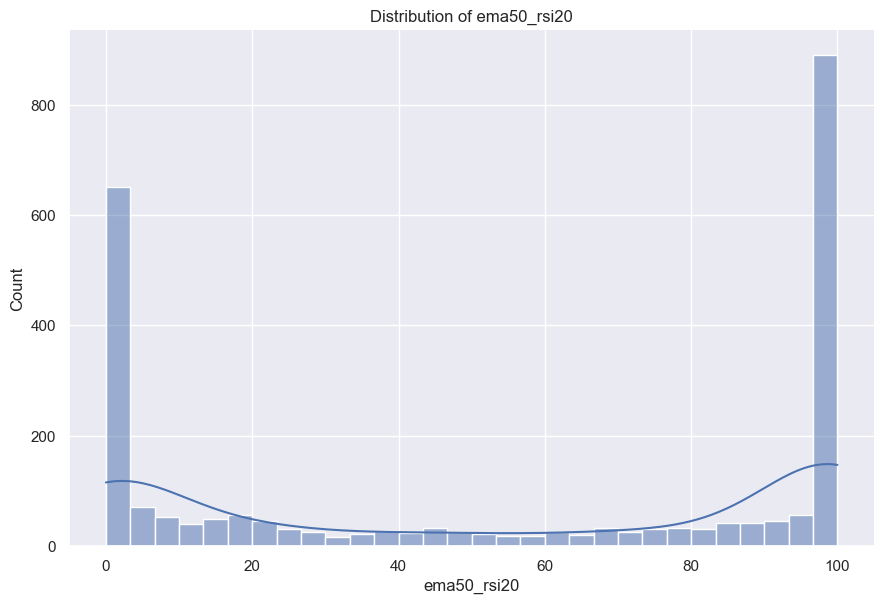

In [7]:
sns.displot(data['ema50_rsi20'], kind="hist", bins=30, kde=True, height=6, aspect=1.5)
plt.title("Distribution of ema50_rsi20")
plt.show()

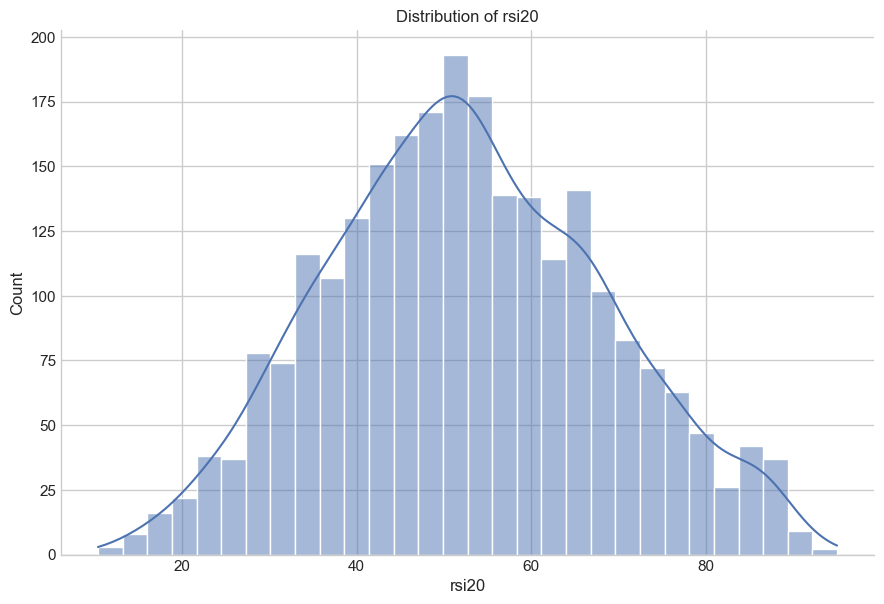

In [18]:
sns.displot(data['rsi20'], kind="hist", bins=30, kde=True, height=6, aspect=1.5)
plt.title("Distribution of rsi20")
plt.show()

In [9]:
price = data['close']
price

timestamp
2018-02-24     9694.51
2018-02-25     9590.00
2018-02-26    10324.00
2018-02-27    10569.04
2018-02-28    10326.76
                ...   
2024-12-26    95791.60
2024-12-27    94299.03
2024-12-28    95300.00
2024-12-29    93738.20
2024-12-30    92792.05
Name: close, Length: 2498, dtype: float64

In [10]:
df = data[['fg', 'pct_fg', 'ema50_rsi20', 'rsi20', 'Returns']]
price = data['close']

size = int(len(df) * 0.8)
X_train = df.iloc[:size, :]
X_test = df.iloc[size:, :]
train_price = price.iloc[:size]
test_price = price.iloc[size:]

X_train.tail()

,fg,pct_fg,ema50_rsi20,rsi20,Returns
timestamp,,,,,
2023-08-13,54,0.08,43.487962,52.232923,-0.004293
2023-08-14,50,-0.056604,46.961217,53.452035,0.004337
2023-08-15,53,0.019231,44.819077,47.495699,-0.007847
2023-08-16,52,0.04,38.936750,42.705577,-0.016078
2023-08-17,50,0.351351,22.532778,25.039749,-0.073340


### Standard HMM

In [11]:
from hmmlearn import hmm

def fit_hmm_and_visualize(X_train, X_test, train_price, test_price, columns, n_regimes=3):
    """
    Fits an HMM model on specified columns of data and visualizes the regimes.
    
    Parameters:
    -----------
    X_train : pandas.DataFrame
        Training data containing the feature columns
    X_test : pandas.DataFrame
        Test data containing the feature columns
    train_price : pandas.Series or array-like
        Price data for the training period
    test_price : pandas.Series or array-like
        Price data for the test period
    columns : str or list of str
        The name(s) of the column(s) to use for HMM training
    n_regimes : int, default=3
        Number of regimes/states to identify
        
    Returns:
    --------
    dict
        Dictionary containing model, states, and performance metrics
    """
    # Convert single column name to list for consistent handling
    if isinstance(columns, str):
        columns = [columns]
    
    # Create feature name for display
    feature_name = ", ".join(columns)
    
    # Step 1: Prepare the data
    # Extract the specified columns from X_train for training
    X_train_hmm = X_train[columns].values
    
    # Step 2: Train the HMM model
    model = hmm.GaussianHMM(n_components=n_regimes, covariance_type="full", n_iter=1000, random_state=42)
    model.fit(X_train_hmm)

    # Step 3: Get the predicted states/regimes for train data
    train_states = model.predict(X_train_hmm)

    # Step 4: Get the predicted states/regimes for test data
    X_test_hmm = X_test[columns].values
    test_states = model.predict(X_test_hmm)

    # Step 5: Compute model evaluation metrics
    # Log likelihood
    log_likelihood = model.score(X_train_hmm)

    # Silhouette score for training data
    silhouette = silhouette_score(X_train_hmm, train_states)

    # Step 6: Calculate returns by regime
    train_returns_by_regime = {}
    for regime in np.unique(train_states):
        regime_returns = X_train.loc[train_states == regime, 'Returns']
        train_returns_by_regime[regime] = {
            'mean': regime_returns.mean(),
            'std': regime_returns.std(),
            'count': len(regime_returns)
        }

    test_returns_by_regime = {}
    for regime in np.unique(test_states):
        regime_returns = X_test.loc[test_states == regime, 'Returns']
        test_returns_by_regime[regime] = {
            'mean': regime_returns.mean(),
            'std': regime_returns.std(),
            'count': len(regime_returns)
        }

    # Step 7: Create visualizations
    plt.figure(figsize=(16, 12))

    # Plot 1: Training data with regimes
    plt.subplot(2, 1, 1)

    # Convert train_price to a Series if it's not already one
    if not isinstance(train_price, pd.Series):
        train_price = pd.Series(train_price, index=X_train.index)

    # Get the datetime index
    dates = train_price.index

    # First plot the full price series as a line
    plt.plot(dates, train_price, 'k-', alpha=0.3)

    # Then plot each regime's points on top
    for i, regime in enumerate(np.unique(train_states)):
        # Create a mask for the current regime
        mask = train_states == regime
        
        # Use boolean indexing with the mask to get dates and prices for this regime
        regime_dates = dates[mask]
        regime_prices = train_price[mask]
        
        plt.plot(regime_dates, regime_prices, 'o', markersize=4, label=f'Regime {regime}')

    plt.title(f'Training Data with HMM Regimes (Features: {feature_name})\nLog Likelihood: {log_likelihood:.2f}, Silhouette Score: {silhouette:.2f}')
    plt.ylabel('Price')
    plt.grid(True)
    plt.legend()
    plt.xticks(rotation=45)

    # Add regime statistics as text
    for i, regime in enumerate(train_returns_by_regime.keys()):
        stats = train_returns_by_regime[regime]
        plt.annotate(
            f"Regime {regime}: Return = {stats['mean']:.4f}, Std = {stats['std']:.4f}, N = {stats['count']}",
            xy=(0.02, 0.95 - i*0.05),
            xycoords='axes fraction',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8)
        )

    # Plot 2: Test data with regimes
    plt.subplot(2, 1, 2)

    # Convert test_price to a Series if it's not already one
    if not isinstance(test_price, pd.Series):
        test_price = pd.Series(test_price, index=X_test.index)

    # Get the datetime index
    test_dates = test_price.index

    # First plot the full price series as a line
    plt.plot(test_dates, test_price, 'k-', alpha=0.3)

    # Then plot each regime's points on top
    for i, regime in enumerate(np.unique(test_states)):
        # Create a mask for the current regime
        mask = test_states == regime
        
        # Use boolean indexing with the mask to get dates and prices for this regime
        regime_dates = test_dates[mask]
        regime_prices = test_price[mask]
        
        plt.plot(regime_dates, regime_prices, 'o', markersize=4, label=f'Regime {regime}')

    plt.title(f'Test Data with HMM Regimes (Features: {feature_name})')
    plt.ylabel('Price')
    plt.xlabel('Time')
    plt.grid(True)
    plt.legend()
    plt.xticks(rotation=45)

    # Add regime statistics as text
    for i, regime in enumerate(test_returns_by_regime.keys()):
        stats = test_returns_by_regime[regime]
        plt.annotate(
            f"Regime {regime}: Return = {stats['mean']:.4f}, Std = {stats['std']:.4f}, N = {stats['count']}",
            xy=(0.02, 0.95 - i*0.05),
            xycoords='axes fraction',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8)
        )

    plt.tight_layout()
    plt.show()

    # Print detailed regime statistics
    print(f"\n=== HMM Analysis using features: {feature_name} ===")
    print("\n=== Training Data Regime Statistics ===")
    for regime, stats in train_returns_by_regime.items():
        print(f"Regime {regime}:")
        print(f"  Mean Return: {stats['mean']:.6f}")
        print(f"  Std Dev: {stats['std']:.6f}")
        print(f"  Count: {stats['count']}")
        print(f"  Percentage: {stats['count']/len(train_states)*100:.2f}%")

    print("\n=== Test Data Regime Statistics ===")
    for regime, stats in test_returns_by_regime.items():
        print(f"Regime {regime}:")
        print(f"  Mean Return: {stats['mean']:.6f}")
        print(f"  Std Dev: {stats['std']:.6f}")
        print(f"  Count: {stats['count']}")
        print(f"  Percentage: {stats['count']/len(test_states)*100:.2f}%")

    # Additional analysis: Transition matrix
    print("\n=== Transition Matrix ===")
    print(pd.DataFrame(model.transmat_, 
                    index=[f"From Regime {i}" for i in range(model.n_components)],
                    columns=[f"To Regime {i}" for i in range(model.n_components)]))

    # Expected duration in each state
    expected_duration = -1.0 / np.log(np.diag(model.transmat_))
    print("\n=== Expected Regime Duration ===")
    for i, duration in enumerate(expected_duration):
        print(f"Regime {i}: {duration:.2f} time periods")
        
    # Return results for further analysis if needed
    results = {
        'model': model,
        'train_states': train_states,
        'test_states': test_states,
        'log_likelihood': log_likelihood,
        'silhouette': silhouette,
        'train_returns_by_regime': train_returns_by_regime,
        'test_returns_by_regime': test_returns_by_regime
    }
    
    return results

# Example usage:
# 1. Single feature
# results_single = fit_hmm_and_visualize(X_train, X_test, train_price, test_price, 'ema50_rsi20', n_regimes=3)

# 2. Multiple features
# results_multi = fit_hmm_and_visualize(X_train, X_test, train_price, test_price, ['ema50_rsi20', 'pct_fg'], n_regimes=3)

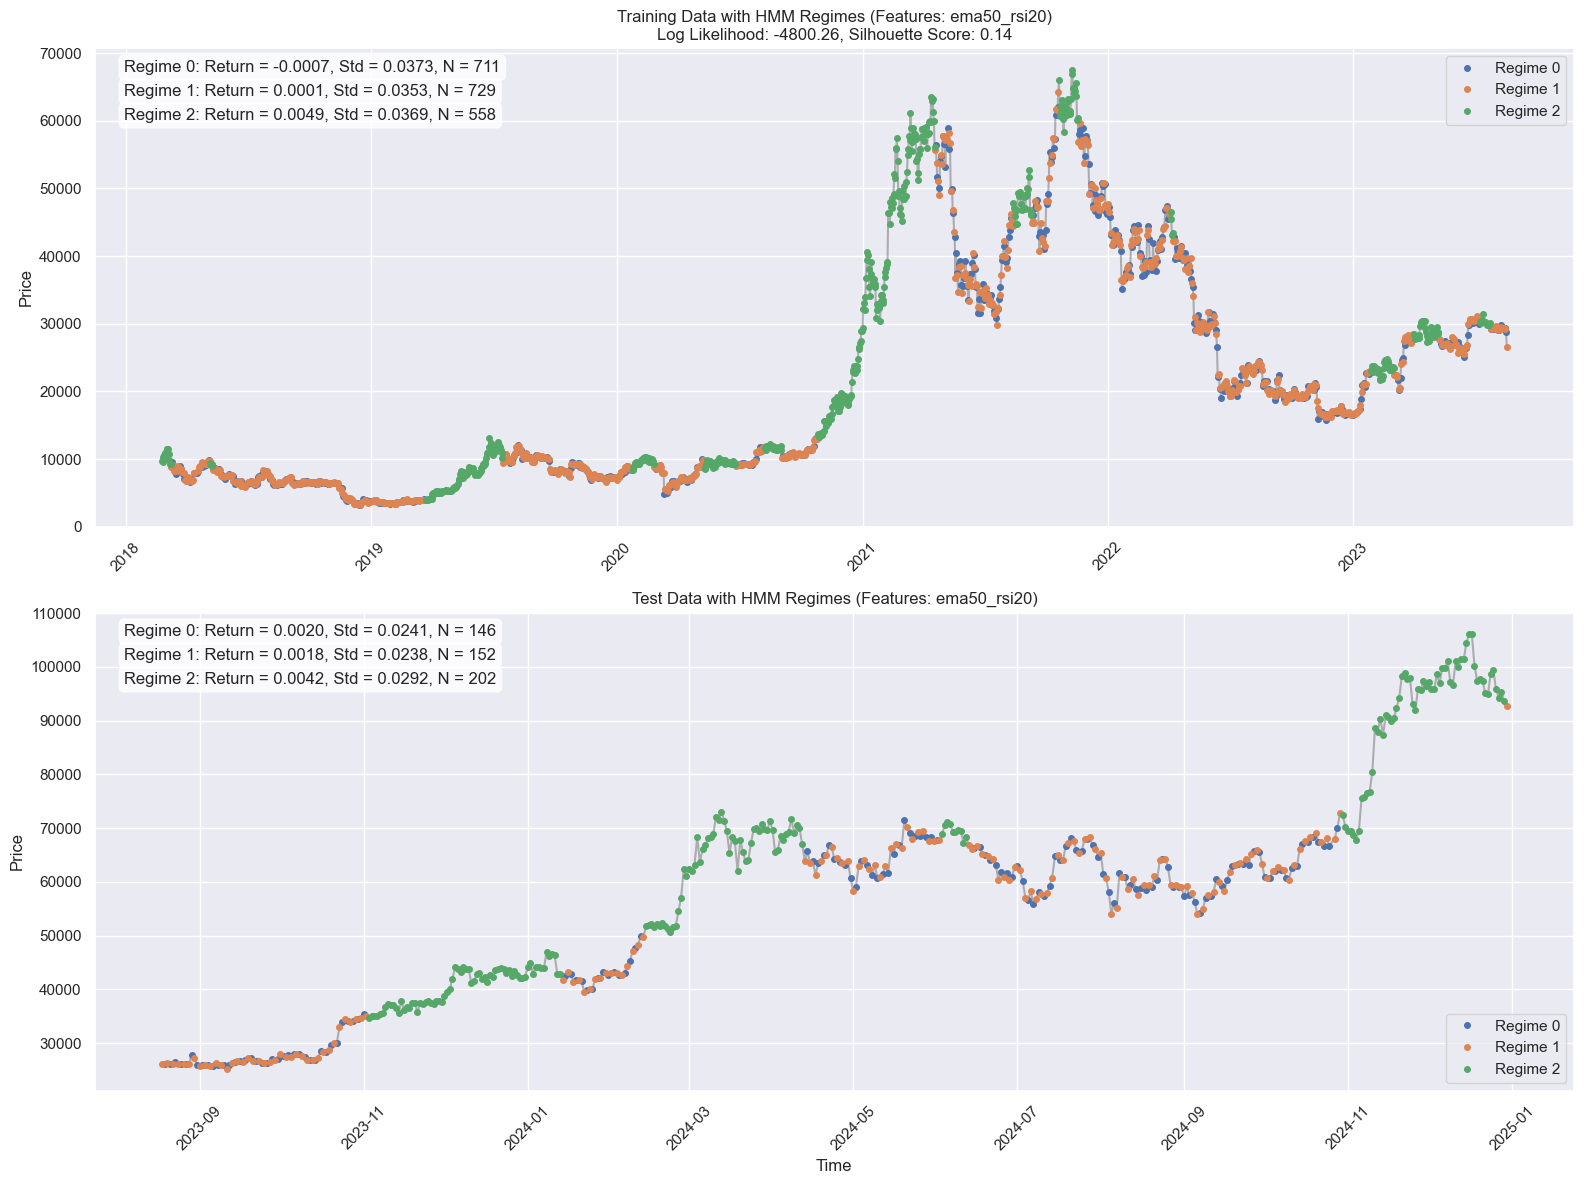


=== HMM Analysis using features: ema50_rsi20 ===

=== Training Data Regime Statistics ===
Regime 0:
  Mean Return: -0.000660
  Std Dev: 0.037326
  Count: 711
  Percentage: 35.59%
Regime 1:
  Mean Return: 0.000070
  Std Dev: 0.035297
  Count: 729
  Percentage: 36.49%
Regime 2:
  Mean Return: 0.004873
  Std Dev: 0.036855
  Count: 558
  Percentage: 27.93%

=== Test Data Regime Statistics ===
Regime 0:
  Mean Return: 0.001991
  Std Dev: 0.024122
  Count: 146
  Percentage: 29.20%
Regime 1:
  Mean Return: 0.001783
  Std Dev: 0.023829
  Count: 152
  Percentage: 30.40%
Regime 2:
  Mean Return: 0.004216
  Std Dev: 0.029163
  Count: 202
  Percentage: 40.40%

=== Transition Matrix ===
               To Regime 0  To Regime 1   To Regime 2
From Regime 0     0.003296     0.996704  1.555438e-08
From Regime 1     0.957574     0.026078  1.634813e-02
From Regime 2     0.000032     0.023265  9.767025e-01

=== Expected Regime Duration ===
Regime 0: 0.17 time periods
Regime 1: 0.27 time periods
Regime 2: 

In [12]:
results_rsi = fit_hmm_and_visualize(X_train, X_test, train_price, test_price, 'ema50_rsi20', n_regimes=3)

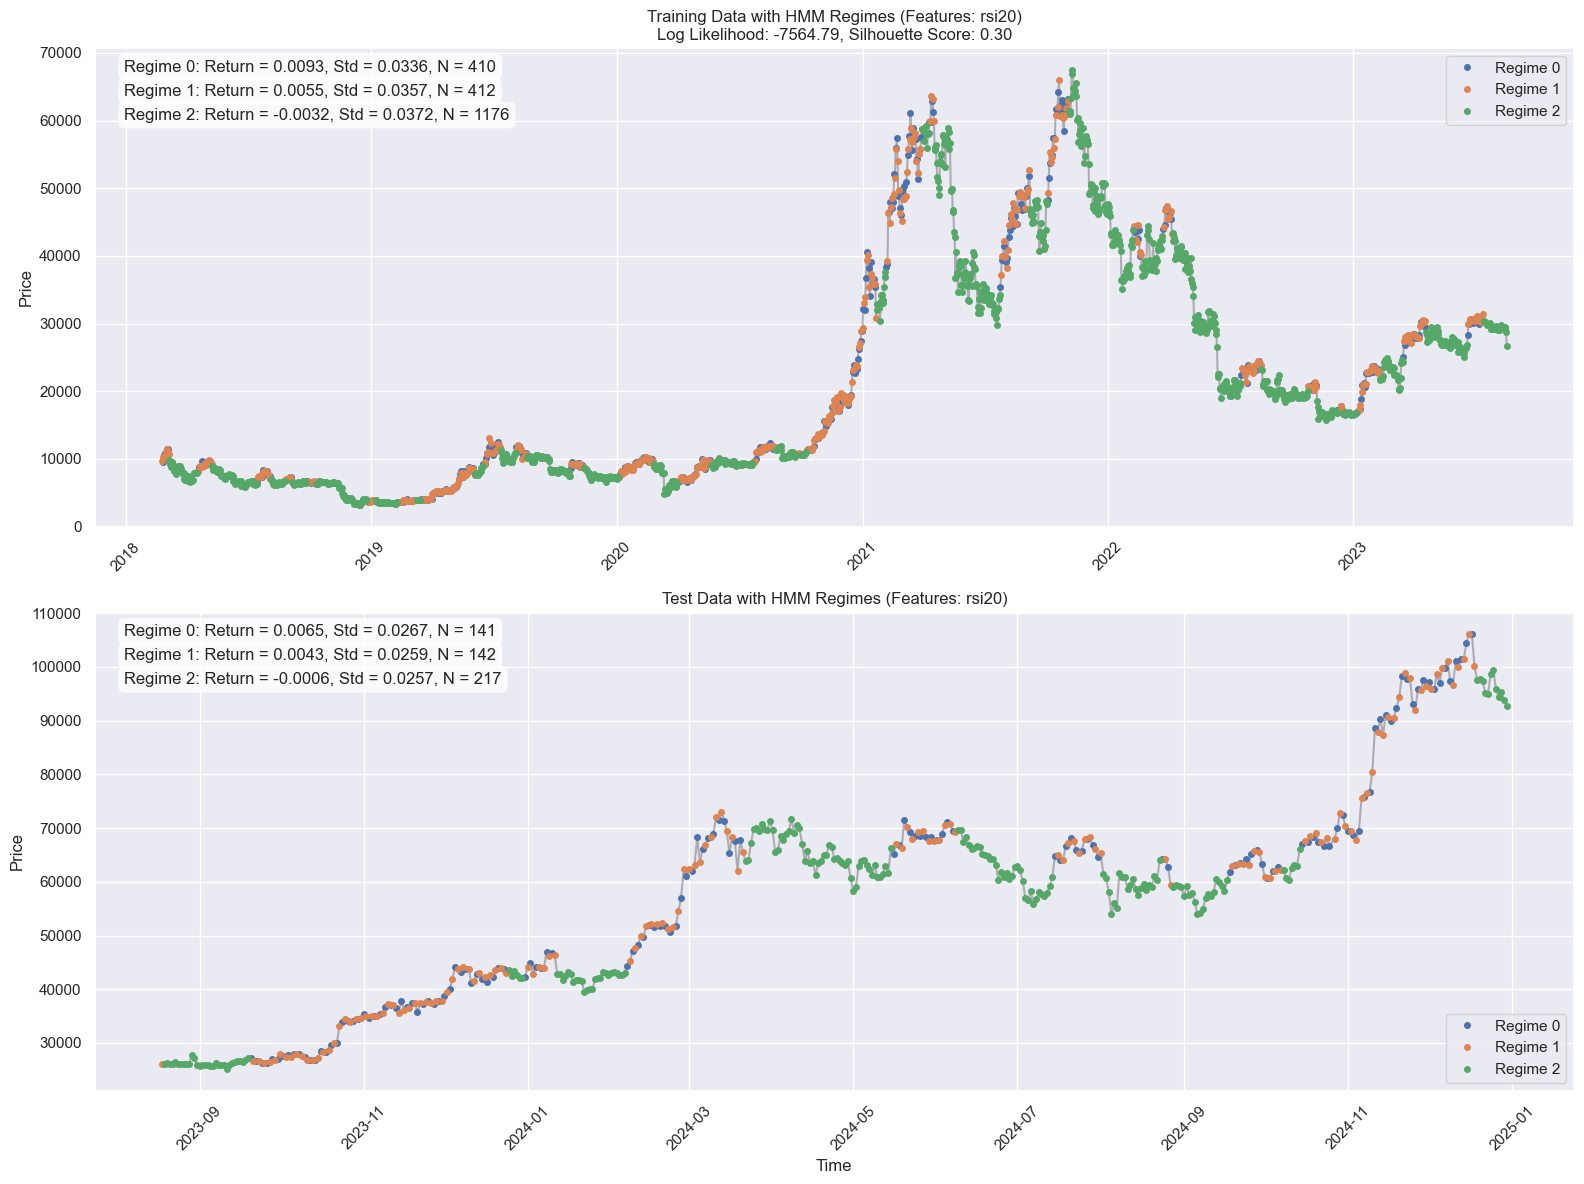


=== HMM Analysis using features: rsi20 ===

=== Training Data Regime Statistics ===
Regime 0:
  Mean Return: 0.009258
  Std Dev: 0.033565
  Count: 410
  Percentage: 20.52%
Regime 1:
  Mean Return: 0.005539
  Std Dev: 0.035694
  Count: 412
  Percentage: 20.62%
Regime 2:
  Mean Return: -0.003212
  Std Dev: 0.037154
  Count: 1176
  Percentage: 58.86%

=== Test Data Regime Statistics ===
Regime 0:
  Mean Return: 0.006521
  Std Dev: 0.026730
  Count: 141
  Percentage: 28.20%
Regime 1:
  Mean Return: 0.004325
  Std Dev: 0.025854
  Count: 142
  Percentage: 28.40%
Regime 2:
  Mean Return: -0.000554
  Std Dev: 0.025704
  Count: 217
  Percentage: 43.40%

=== Transition Matrix ===
               To Regime 0  To Regime 1  To Regime 2
From Regime 0     0.001454     0.998493     0.000053
From Regime 1     0.905814     0.016948     0.077238
From Regime 2     0.019618     0.007378     0.973005

=== Expected Regime Duration ===
Regime 0: 0.15 time periods
Regime 1: 0.25 time periods
Regime 2: 36.54 ti

In [13]:
results_rsi = fit_hmm_and_visualize(X_train, X_test, train_price, test_price, 'rsi20', n_regimes=3)

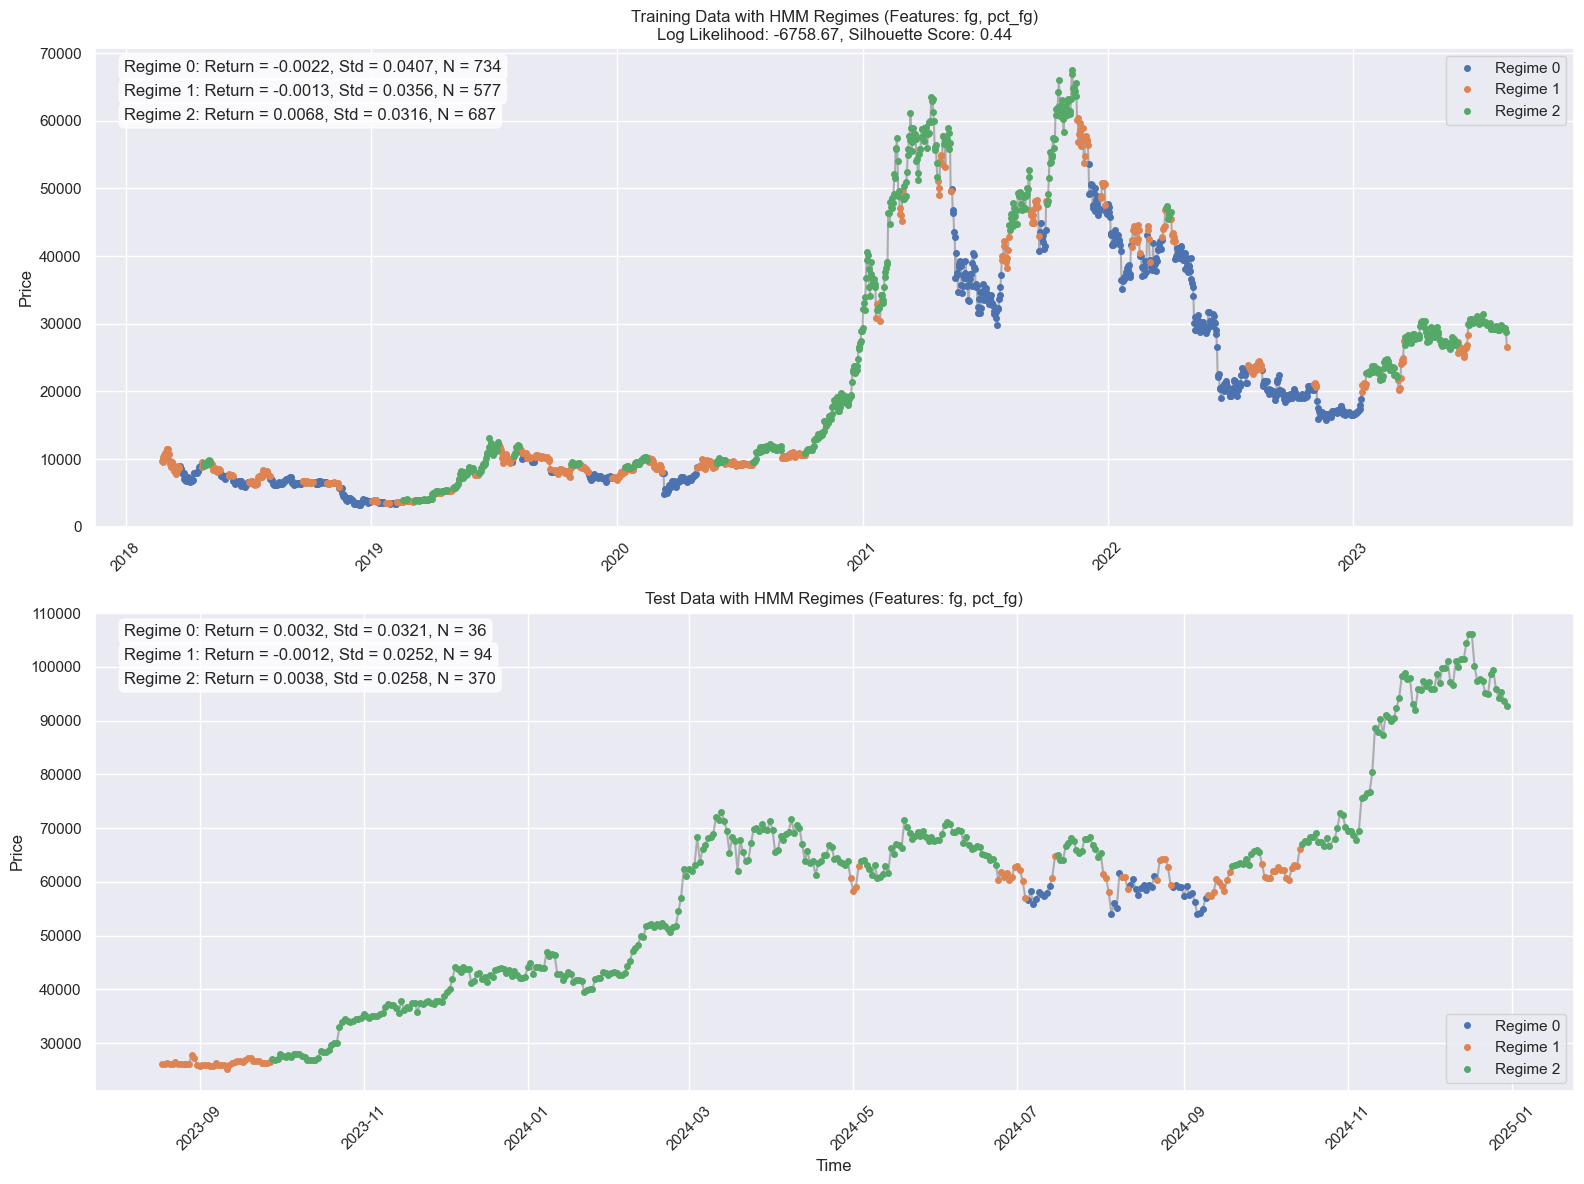


=== HMM Analysis using features: fg, pct_fg ===

=== Training Data Regime Statistics ===
Regime 0:
  Mean Return: -0.002221
  Std Dev: 0.040681
  Count: 734
  Percentage: 36.74%
Regime 1:
  Mean Return: -0.001331
  Std Dev: 0.035617
  Count: 577
  Percentage: 28.88%
Regime 2:
  Mean Return: 0.006839
  Std Dev: 0.031619
  Count: 687
  Percentage: 34.38%

=== Test Data Regime Statistics ===
Regime 0:
  Mean Return: 0.003159
  Std Dev: 0.032084
  Count: 36
  Percentage: 7.20%
Regime 1:
  Mean Return: -0.001244
  Std Dev: 0.025167
  Count: 94
  Percentage: 18.80%
Regime 2:
  Mean Return: 0.003828
  Std Dev: 0.025759
  Count: 370
  Percentage: 74.00%

=== Transition Matrix ===
                To Regime 0  To Regime 1   To Regime 2
From Regime 0  9.666757e-01     0.033324  9.890902e-29
From Regime 1  4.140679e-02     0.906627  5.196620e-02
From Regime 2  5.464598e-82     0.043337  9.566630e-01

=== Expected Regime Duration ===
Regime 0: 29.51 time periods
Regime 1: 10.20 time periods
Regime

In [14]:
results_fg = fit_hmm_and_visualize(X_train, X_test, train_price, test_price, ['fg', 'pct_fg'], n_regimes=3)

### DNN HMM

In [15]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle

# Create output directory for saved models and figures
os.makedirs("dnn_hmm_models", exist_ok=True)
os.makedirs("dnn_hmm_output", exist_ok=True)

# Set matplotlib style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("PyTorch DNN-HMM Analysis for Market Regimes - Single Feature Version")
print("=" * 60)

# Define Feature Extractor (Neural Network) class
class FeatureExtractor(nn.Module):
    """
    Neural network for feature extraction in PyTorch.
    """
    def __init__(self, input_dim, hidden_dims=[64, 32], embedding_dim=16, dropout_rate=0.2):
        super(FeatureExtractor, self).__init__()
        
        # Build layers
        layers = []
        prev_dim = input_dim
        
        # Add hidden layers
        for dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, dim))
            layers.append(nn.ReLU())
            layers.append(nn.BatchNorm1d(dim))
            layers.append(nn.Dropout(dropout_rate))
            prev_dim = dim
        
        # Add embedding layer
        layers.append(nn.Linear(prev_dim, embedding_dim))
        layers.append(nn.Tanh())
        
        # Combine layers
        self.model = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.model(x)

# Define Hidden Markov Model class
class HMM:
    """
    Hidden Markov Model implementation using PyTorch.
    """
    def __init__(self, n_states, n_dims, init_type='stable', device='cpu'):
        self.n_states = n_states
        self.n_dims = n_dims
        self.device = device
        
        # Initialize parameters
        if init_type == 'random':
            # Initial state probabilities (pi)
            self.log_pi = torch.randn(n_states).float().to(device)
            
            # Transition matrix (A)
            self.log_A = torch.randn(n_states, n_states).float().to(device)
            
            # Emission parameters for Gaussian emissions
            self.means = torch.randn(n_states, n_dims).float().to(device)
            # Use log scale for numerical stability
            self.log_vars = torch.randn(n_states, n_dims).float().to(device)
        else:
            # More stable initialization
            # Initial state probabilities (pi) - uniform
            self.log_pi = torch.log(torch.ones(n_states).to(device) / n_states)
            
            # Transition matrix (A) - slightly biased to stay in same state
            A = torch.ones(n_states, n_states).to(device) * 0.1
            for i in range(n_states):
                A[i, i] = 0.8  # High self-transition probability
            A = A / A.sum(dim=1, keepdim=True)  # Normalize rows
            self.log_A = torch.log(A)
            
            # Emission parameters - spread out means
            self.means = torch.zeros(n_states, n_dims).to(device)
            for i in range(n_states):
                self.means[i] = torch.randn(n_dims).to(device) * 2.0 + i  # Separated means
            
            # Start with unit variance
            self.log_vars = torch.zeros(n_states, n_dims).to(device)
    
    def normalize_parameters(self):
        """Normalize parameters to ensure valid probabilities."""
        # Normalize initial state probabilities
        log_pi_norm = self.log_pi - torch.logsumexp(self.log_pi, dim=0)
        
        # Normalize transition probabilities
        log_A_norm = self.log_A - torch.logsumexp(self.log_A, dim=1, keepdim=True)
        
        return log_pi_norm, log_A_norm
    
    def emission_log_probs(self, x):
        """
        Calculate emission log probabilities for all states and observations.
        """
        batch_size = x.shape[0]
        log_emissions = torch.zeros(batch_size, self.n_states).to(self.device)
        
        for j in range(self.n_states):
            # Calculate Gaussian log probability
            vars_j = torch.exp(self.log_vars[j])
            diff = x - self.means[j]
            log_p = -0.5 * (torch.log(2 * np.pi * vars_j) + (diff ** 2) / vars_j)
            log_emissions[:, j] = log_p.sum(dim=1)
        
        return log_emissions
    
    def viterbi_algorithm(self, log_emissions):
        """
        Viterbi algorithm to find the most likely state sequence.
        """
        batch_size = log_emissions.shape[0]
        
        # Normalize parameters
        log_pi_norm, log_A_norm = self.normalize_parameters()
        
        # Initialize Viterbi variables
        delta = torch.zeros(batch_size, self.n_states).to(self.device)
        psi = torch.zeros(batch_size, self.n_states, dtype=torch.long).to(self.device)
        
        # Initialization
        delta[0] = log_pi_norm + log_emissions[0]
        
        # Recursion
        for t in range(1, batch_size):
            for j in range(self.n_states):
                probs = delta[t-1] + log_A_norm[:, j]
                psi[t, j] = torch.argmax(probs)
                delta[t, j] = probs[psi[t, j]] + log_emissions[t, j]
        
        # Backtracking
        states = torch.zeros(batch_size, dtype=torch.long).to(self.device)
        states[-1] = torch.argmax(delta[-1])
        
        for t in range(batch_size-2, -1, -1):
            states[t] = psi[t+1, states[t+1]]
        
        return states
    
    def forward_algorithm(self, log_emissions):
        """
        Forward algorithm to calculate log-likelihood.
        """
        batch_size = log_emissions.shape[0]
        
        # Normalize parameters
        log_pi_norm, log_A_norm = self.normalize_parameters()
        
        # Initialize forward variables
        log_alpha = torch.zeros(batch_size, self.n_states).to(self.device)
        
        # Initialization
        log_alpha[0] = log_pi_norm + log_emissions[0]
        
        # Recursion
        for t in range(1, batch_size):
            for j in range(self.n_states):
                log_alpha[t, j] = torch.logsumexp(log_alpha[t-1] + log_A_norm[:, j], dim=0) + log_emissions[t, j]
        
        # Calculate log-likelihood
        log_likelihood = torch.logsumexp(log_alpha[-1], dim=0)
        
        return log_likelihood
    
    def fit(self, x, max_iter=100, tol=1e-6):
        """
        Fit the HMM using Baum-Welch algorithm.
        """
        prev_ll = -float('inf')
        
        for iteration in range(max_iter):
            # E-step: Calculate log emission probabilities
            log_emissions = self.emission_log_probs(x)
            
            # Calculate log-likelihood
            log_likelihood = self.forward_algorithm(log_emissions)
            
            # Check convergence
            if log_likelihood - prev_ll < tol:
                print(f"Converged at iteration {iteration} with log-likelihood: {log_likelihood.item():.4f}")
                break
                
            prev_ll = log_likelihood
            
            # M-step: Need to implement a proper Baum-Welch algorithm here
            # This is a simplified version that just updates means and variances
            
            # Get state assignments (hard assignment for simplicity)
            states = self.viterbi_algorithm(log_emissions)
            
            # Update emission parameters
            for j in range(self.n_states):
                mask = (states == j)
                if mask.sum() > 0:
                    # Update means
                    self.means[j] = x[mask].mean(dim=0)
                    # Update variances (with minimum variance for stability)
                    vars_j = torch.clamp(((x[mask] - self.means[j]) ** 2).mean(dim=0), min=1e-6)
                    self.log_vars[j] = torch.log(vars_j)
            
            # Update transition parameters (simplified)
            state_transitions = torch.zeros((self.n_states, self.n_states)).to(self.device)
            for t in range(1, len(states)):
                state_transitions[states[t-1], states[t]] += 1
                
            # Add small value to prevent zeros and normalize
            state_transitions = state_transitions + 1e-6
            state_transitions = state_transitions / state_transitions.sum(dim=1, keepdim=True)
            self.log_A = torch.log(state_transitions)
            
            # Print progress every 10 iterations
            if iteration % 10 == 0:
                print(f"Iteration {iteration}, Log-likelihood: {log_likelihood.item():.4f}")
                
                # Print state distribution
                state_counts = torch.bincount(states.cpu(), minlength=self.n_states)
                percentages = 100 * state_counts / len(states)
                for s in range(self.n_states):
                    print(f"  State {s}: {state_counts[s].item()} samples ({percentages[s].item():.1f}%)")
        
        return log_likelihood.item()
    
    def predict(self, x):
        """
        Predict states using Viterbi algorithm.
        """
        log_emissions = self.emission_log_probs(x)
        states = self.viterbi_algorithm(log_emissions)
        return states.cpu().numpy()

def train_single_feature_dnnhmm(X_train, X_test, train_price, test_price, feature_column, n_regimes=3, 
                              hidden_dims=[64, 32], embedding_dim=16, n_epochs=100, learning_rate=0.001,
                              batch_size=32, device=None, hmm_max_iter=100):
    """
    Trains a DNN-HMM model on a single feature and visualizes the results.
    Also saves the model for future use.
    
    Parameters:
    -----------
    X_train : pandas.DataFrame
        Training data containing the feature column
    X_test : pandas.DataFrame
        Test data containing the feature column
    train_price : pandas.Series or array-like
        Price data for the training period
    test_price : pandas.Series or array-like
        Price data for the test period
    feature_column : str
        The name of the column to use for training
    n_regimes : int, default=3
        Number of regimes/states to identify
    hidden_dims : list
        Dimensions of hidden layers in the neural network
    embedding_dim : int
        Dimension of the embedding space
    n_epochs : int
        Number of neural network training epochs
    learning_rate : float
        Learning rate for optimization
    batch_size : int
        Batch size for training
    device : str
        Device for PyTorch computations ('cuda' or 'cpu')
    hmm_max_iter : int
        Maximum number of HMM training iterations
        
    Returns:
    --------
    dict
        Dictionary containing model, states, and performance metrics
    """
    # Determine device for PyTorch
    if device is None:
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Using device: {device}")
    
    print(f"Training DNN-HMM with {n_regimes} regimes on feature: {feature_column}")
    
    # Step 1: Prepare the data for training
    try:
        # Extract feature column and convert to float64
        X_train_subset = X_train[[feature_column]].copy()
        X_train_subset[feature_column] = pd.to_numeric(X_train_subset[feature_column], errors='coerce')
        
        # Drop rows with NaN values
        X_train_subset = X_train_subset.dropna()
        
        if X_train_subset.empty:
            raise ValueError("After cleaning, training data is empty. Check your column for non-numeric values.")
        
        print(f"Training data shape after cleaning: {X_train_subset.shape}")
    except Exception as e:
        raise ValueError(f"Error preparing training data: {str(e)}")
    
    # Step 2: Scale the data
    print("Scaling data...")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_subset)
    
    # Step 3: Train the neural network for feature extraction
    print("Training neural network for feature extraction...")
    X_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
    
    # Create dataset and dataloader
    dataset = TensorDataset(X_tensor, X_tensor)  # Self-supervised
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    # Create model
    nn_model = FeatureExtractor(
        input_dim=X_train_scaled.shape[1],
        hidden_dims=hidden_dims,
        embedding_dim=embedding_dim,
        dropout_rate=0.2
    ).to(device)
    
    # Define loss and optimizer
    criterion = nn.MSELoss()
    optimizer = optim.Adam(nn_model.parameters(), lr=learning_rate)
    
    # Train the neural network
    print(f"Training neural network for {n_epochs} epochs...")
    for epoch in range(n_epochs):
        total_loss = 0
        for inputs, targets in dataloader:
            # Forward pass
            outputs = nn_model(inputs)
            
            # Loss calculation - reconstruction loss
            loss = criterion(outputs, inputs)
            
            # Backward pass and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        # Print progress periodically
        if epoch % 10 == 0 or epoch == n_epochs - 1:
            avg_loss = total_loss / len(dataloader)
            print(f"Epoch {epoch+1}/{n_epochs}, Loss: {avg_loss:.6f}")
    
    # Generate embeddings
    nn_model.eval()
    with torch.no_grad():
        embeddings = nn_model(X_tensor).cpu().numpy()
    
    # Step 4: Train the HMM on the embeddings
    print(f"Training HMM with {n_regimes} regimes on embeddings...")
    embeddings_tensor = torch.tensor(embeddings, dtype=torch.float32).to(device)
    hmm_model = HMM(n_states=n_regimes, n_dims=embedding_dim, init_type='stable', device=device)
    log_likelihood = hmm_model.fit(embeddings_tensor, max_iter=hmm_max_iter)
    
    # Generate state predictions for training data
    print("Generating regime predictions...")
    train_states = hmm_model.predict(embeddings_tensor)
    
    # Calculate silhouette score if possible
    try:
        silhouette = silhouette_score(embeddings, train_states)
        print(f"Silhouette score: {silhouette:.4f}")
    except Exception as e:
        silhouette = 0
        print(f"Error calculating silhouette score: {str(e)}")
    
    # Step 5: Process test data
    try:
        # Extract feature column and convert to float64
        X_test_subset = X_test[[feature_column]].copy()
        X_test_subset[feature_column] = pd.to_numeric(X_test_subset[feature_column], errors='coerce')
        
        # Drop rows with NaN values
        X_test_subset = X_test_subset.dropna()
        
        if X_test_subset.empty:
            raise ValueError("After cleaning, test data is empty. Check your column for non-numeric values.")
        
        print(f"Test data shape after cleaning: {X_test_subset.shape}")
        
        # Scale the data
        X_test_scaled = scaler.transform(X_test_subset)
        
        # Get embeddings
        test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
        with torch.no_grad():
            test_embeddings = nn_model(test_tensor).cpu().numpy()
        
        # Predict states
        test_embeddings_tensor = torch.tensor(test_embeddings, dtype=torch.float32).to(device)
        test_states = hmm_model.predict(test_embeddings_tensor)
    except Exception as e:
        raise ValueError(f"Error processing test data: {str(e)}")

    # Step 6: Calculate returns by regime
    train_returns_by_regime = {}
    train_indices = X_train_subset.index  # Use the cleaned indices
    
    for regime in np.unique(train_states):
        regime_mask = train_states == regime
        regime_indices = train_indices[regime_mask]
        
        # Make sure 'Returns' column exists and filter to regime indices
        if 'Returns' in X_train.columns:
            regime_returns = X_train.loc[regime_indices, 'Returns']
            train_returns_by_regime[regime] = {
                'mean': regime_returns.mean(),
                'std': regime_returns.std(),
                'count': len(regime_returns)
            }
        else:
            train_returns_by_regime[regime] = {
                'mean': np.nan,
                'std': np.nan,
                'count': sum(regime_mask)
            }
            print("Warning: 'Returns' column not found in training data")

    test_returns_by_regime = {}
    test_indices = X_test_subset.index  # Use the cleaned indices
    
    for regime in np.unique(test_states):
        regime_mask = test_states == regime
        regime_indices = test_indices[regime_mask]
        
        # Make sure 'Returns' column exists and filter to regime indices
        if 'Returns' in X_test.columns:
            regime_returns = X_test.loc[regime_indices, 'Returns']
            test_returns_by_regime[regime] = {
                'mean': regime_returns.mean(),
                'std': regime_returns.std(),
                'count': len(regime_returns)
            }
        else:
            test_returns_by_regime[regime] = {
                'mean': np.nan,
                'std': np.nan,
                'count': sum(regime_mask)
            }
            print("Warning: 'Returns' column not found in test data")

    # Step 7: Create visualizations
    plt.figure(figsize=(16, 12))

    # Plot 1: Training data with regimes
    plt.subplot(2, 1, 1)

    # Convert train_price to a Series if it's not already one
    if not isinstance(train_price, pd.Series):
        train_price = pd.Series(train_price, index=X_train.index)

    # Get the datetime index
    dates = train_price.index
    clean_dates = dates.intersection(train_indices)  # Only use dates that survived cleaning

    # First plot the full price series as a line
    plt.plot(dates, train_price, 'k-', alpha=0.3)

    # Then plot each regime's points on top
    for i, regime in enumerate(np.unique(train_states)):
        # Create a mask for the current regime
        mask = train_states == regime
        
        # Map back to original indices
        regime_indices = train_indices[mask]
        
        # Use only dates that exist in both sets
        valid_indices = regime_indices.intersection(dates)
        
        # Plot points for this regime
        if len(valid_indices) > 0:
            plt.plot(valid_indices, train_price.loc[valid_indices], 'o', markersize=4, label=f'Regime {regime}')

    plt.title(f'Training Data with DNN-HMM Regimes (Feature: {feature_column})\nLog Likelihood: {log_likelihood:.2f}, Silhouette Score: {silhouette:.2f}')
    plt.ylabel('Price')
    plt.grid(True)
    plt.legend()
    plt.xticks(rotation=45)

    # Add regime statistics as text
    for i, regime in enumerate(train_returns_by_regime.keys()):
        stats = train_returns_by_regime[regime]
        plt.annotate(
            f"Regime {regime}: Return = {stats['mean']:.4f}, Std = {stats['std']:.4f}, N = {stats['count']}",
            xy=(0.02, 0.95 - i*0.05),
            xycoords='axes fraction',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8)
        )

    # Plot 2: Test data with regimes
    plt.subplot(2, 1, 2)

    # Convert test_price to a Series if it's not already one
    if not isinstance(test_price, pd.Series):
        test_price = pd.Series(test_price, index=X_test.index)

    # Get the datetime index
    test_dates = test_price.index
    clean_test_dates = test_dates.intersection(test_indices)  # Only use dates that survived cleaning

    # First plot the full price series as a line
    plt.plot(test_dates, test_price, 'k-', alpha=0.3)

    # Then plot each regime's points on top
    for i, regime in enumerate(np.unique(test_states)):
        # Create a mask for the current regime
        mask = test_states == regime
        
        # Map back to original indices
        regime_indices = test_indices[mask]
        
        # Use only dates that exist in both sets
        valid_indices = regime_indices.intersection(test_dates)
        
        # Plot points for this regime
        if len(valid_indices) > 0:
            plt.plot(valid_indices, test_price.loc[valid_indices], 'o', markersize=4, label=f'Regime {regime}')

    plt.title(f'Test Data with DNN-HMM Regimes (Feature: {feature_column})')
    plt.ylabel('Price')
    plt.xlabel('Time')
    plt.grid(True)
    plt.legend()
    plt.xticks(rotation=45)

    # Add regime statistics as text
    for i, regime in enumerate(test_returns_by_regime.keys()):
        stats = test_returns_by_regime[regime]
        plt.annotate(
            f"Regime {regime}: Return = {stats['mean']:.4f}, Std = {stats['std']:.4f}, N = {stats['count']}",
            xy=(0.02, 0.95 - i*0.05),
            xycoords='axes fraction',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8)
        )

    plt.tight_layout()
    plt.savefig(f"dnn_hmm_output/dnnhmm_regimes_{feature_column}.png")
    plt.show()

    # Print detailed regime statistics
    print(f"\n=== DNN-HMM Analysis using feature: {feature_column} ===")
    print("\n=== Training Data Regime Statistics ===")
    for regime, stats in train_returns_by_regime.items():
        print(f"Regime {regime}:")
        print(f"  Mean Return: {stats['mean']:.6f}")
        print(f"  Std Dev: {stats['std']:.6f}")
        print(f"  Count: {stats['count']}")
        print(f"  Percentage: {stats['count']/len(train_states)*100:.2f}%")

    print("\n=== Test Data Regime Statistics ===")
    for regime, stats in test_returns_by_regime.items():
        print(f"Regime {regime}:")
        print(f"  Mean Return: {stats['mean']:.6f}")
        print(f"  Std Dev: {stats['std']:.6f}")
        print(f"  Count: {stats['count']}")
        print(f"  Percentage: {stats['count']/len(test_states)*100:.2f}%")
    
    # Step 8: Save the model components for future use
    model_save_path = f"dnn_hmm_models/dnnhmm_{feature_column}"
    os.makedirs(model_save_path, exist_ok=True)
    
    # Save neural network model
    torch.save(nn_model.state_dict(), f"{model_save_path}/nn_model.pth")
    
    # Save HMM parameters
    hmm_params = {
        'log_pi': hmm_model.log_pi.cpu().numpy(),
        'log_A': hmm_model.log_A.cpu().numpy(),
        'means': hmm_model.means.cpu().numpy(),
        'log_vars': hmm_model.log_vars.cpu().numpy(),
        'n_states': hmm_model.n_states,
        'n_dims': hmm_model.n_dims
    }
    with open(f"{model_save_path}/hmm_params.pkl", 'wb') as f:
        pickle.dump(hmm_params, f)
    
    # Save scaler
    with open(f"{model_save_path}/scaler.pkl", 'wb') as f:
        pickle.dump(scaler, f)
    
    # Save model configuration
    model_config = {
        'feature_column': feature_column,
        'n_regimes': n_regimes,
        'hidden_dims': hidden_dims,
        'embedding_dim': embedding_dim,
        'input_dim': X_train_scaled.shape[1],
        'silhouette': silhouette,
        'log_likelihood': log_likelihood
    }
    with open(f"{model_save_path}/config.pkl", 'wb') as f:
        pickle.dump(model_config, f)
    
    print(f"Model saved to {model_save_path}")
    
    # Return results for further analysis if needed
    results = {
        'nn_model': nn_model,
        'hmm_model': hmm_model,
        'scaler': scaler,
        'train_states': train_states,
        'test_states': test_states,
        'train_indices': train_indices,
        'test_indices': test_indices,
        'log_likelihood': log_likelihood,
        'silhouette': silhouette,
        'train_returns_by_regime': train_returns_by_regime,
        'test_returns_by_regime': test_returns_by_regime,
        'config': model_config
    }
    
    return results

def load_dnnhmm_model(feature_column, device=None):
    """
    Load a previously saved DNN-HMM model.
    
    Parameters:
    -----------
    feature_column : str
        The feature column name used when training the model
    device : str
        Device for PyTorch computations ('cuda' or 'cpu')
        
    Returns:
    --------
    dict
        Dictionary containing loaded model components
    """
    if device is None:
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    model_path = f"dnn_hmm_models/dnnhmm_{feature_column}"
    if not os.path.exists(model_path):
        raise ValueError(f"No saved model found for feature {feature_column}")
    
    # Load model configuration
    with open(f"{model_path}/config.pkl", 'rb') as f:
        config = pickle.load(f)
    
    # Load neural network
    nn_model = FeatureExtractor(
        input_dim=config['input_dim'],
        hidden_dims=config['hidden_dims'],
        embedding_dim=config['embedding_dim']
    ).to(device)
    nn_model.load_state_dict(torch.load(f"{model_path}/nn_model.pth", map_location=device))
    nn_model.eval()
    
    # Load HMM parameters
    with open(f"{model_path}/hmm_params.pkl", 'rb') as f:
        hmm_params = pickle.load(f)
    
    # Create HMM model and set parameters
    hmm_model = HMM(
        n_states=hmm_params['n_states'],
        n_dims=hmm_params['n_dims'],
        device=device
    )
    hmm_model.log_pi = torch.tensor(hmm_params['log_pi'], dtype=torch.float32).to(device)
    hmm_model.log_A = torch.tensor(hmm_params['log_A'], dtype=torch.float32).to(device)
    hmm_model.means = torch.tensor(hmm_params['means'], dtype=torch.float32).to(device)
    hmm_model.log_vars = torch.tensor(hmm_params['log_vars'], dtype=torch.float32).to(device)
    
    # Load scaler
    with open(f"{model_path}/scaler.pkl", 'rb') as f:
        scaler = pickle.load(f)
    
    print(f"Model for feature {feature_column} loaded from {model_path}")
    
    return {
        'nn_model': nn_model,
        'hmm_model': hmm_model,
        'scaler': scaler,
        'config': config
    }

def predict_regimes_with_saved_model(model_dict, X_new):
    """
    Predict regimes using a loaded model.
    
    Parameters:
    -----------
    model_dict : dict
        Dictionary containing model components from load_dnnhmm_model()
    X_new : pandas.DataFrame
        New data containing the feature column
        
    Returns:
    --------
    numpy.ndarray
        Predicted regimes
    """
    feature_column = model_dict['config']['feature_column']
    nn_model = model_dict['nn_model']
    hmm_model = model_dict['hmm_model']
    scaler = model_dict['scaler']
    device = next(nn_model.parameters()).device
    
    # Extract and preprocess feature
    X_subset = X_new[[feature_column]].copy()
    X_subset[feature_column] = pd.to_numeric(X_subset[feature_column], errors='coerce')
    X_subset = X_subset.dropna()
    
    if X_subset.empty:
        raise ValueError("After preprocessing, no valid data points remain.")
    
    # Scale the data
    X_scaled = scaler.transform(X_subset)
    
    # Generate embeddings
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(device)
    nn_model.eval()
    with torch.no_grad():
        embeddings = nn_model(X_tensor)
    
    # Predict states using HMM
    states = hmm_model.predict(embeddings)
    
    # Create Series with predicted regimes
    regimes = pd.Series(states, index=X_subset.index, name='Regime')
    
    return regimes

def visualize_regimes(regimes, prices, title="Market Regimes"):
    """
    Visualize regimes with prices.
    
    Parameters:
    -----------
    regimes : pandas.Series
        Predicted regimes with datetime index
    prices : pandas.Series
        Price data with datetime index
    title : str
        Plot title
        
    Returns:
    --------
    matplotlib.figure.Figure
        Figure with regime visualization
    """
    # Create DataFrame with price and regime data
    df = pd.DataFrame({
        'Price': prices,
        'Regime': regimes
    })
    
    # Count unique regimes
    n_regimes = len(np.unique(regimes))
    
    # Create figure and axes
    fig, ax1 = plt.subplots(figsize=(15, 8))
    
    # Plot prices
    ax1.plot(df.index, df['Price'], color='black', alpha=0.6, linewidth=1, label='Price')
    ax1.set_ylabel('Price', fontsize=12)
    ax1.set_xlabel('Date', fontsize=12)
    ax1.grid(True, alpha=0.3)
    
    # Get colors for regimes
    colors = plt.cm.tab10(np.linspace(0, 1, n_regimes))
    
    # Create background colors for regimes
    prev_regime = regimes.iloc[0]
    start_idx = 0
    
    for i in range(1, len(regimes)):
        regime = regimes.iloc[i]
        if regime != prev_regime or i == len(regimes) - 1:
            # Mark end of previous regime
            end_idx = i-1 if regime != prev_regime else i
            # Color region based on regime
            plt.axvspan(regimes.index[start_idx], regimes.index[end_idx], 
                        alpha=0.3, color=colors[prev_regime], label=f'Regime {prev_regime}')
            # Start new region
            start_idx = i
            prev_regime = regime
    
    # Handle legend with unique labels
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), loc='upper left')
    
    plt.title(title, fontsize=14)
    plt.tight_layout()
    
    return fig

def analyze_returns_by_regime(returns, regimes, title="Returns by Regime"):
    """
    Create visualizations for analyzing returns by regime.
    
    Parameters:
    -----------
    returns : pandas.Series
        Returns data with datetime index
    regimes : pandas.Series
        Predicted regimes with matching index
    title : str
        Plot title
        
    Returns:
    --------
    matplotlib.figure.Figure
        Figure with returns analysis
    """
    # Create a DataFrame with regimes and returns
    regime_returns = pd.DataFrame({
        'Regime': regimes,
        'Returns': returns
    })
    
    # Calculate statistics for each regime
    regime_stats = regime_returns.groupby('Regime')['Returns'].agg([
        ('Mean', 'mean'),
        ('Median', 'median'),
        ('Std', 'std'),
        ('Min', 'min'),
        ('Max', 'max'),
        ('Count', 'count')
    ])
    
    # Calculate average returns and volatility
    regime_stats['Mean_Pct'] = regime_stats['Mean'] * 100
    regime_stats['Std_Pct'] = regime_stats['Std'] * 100
    
    # Calculate percentage of days in each regime
    total_days = len(regime_returns)
    regime_stats['Percentage'] = (regime_stats['Count'] / total_days) * 100
    
    # Create figure with multiple subplots
    fig, axs = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle(title, fontsize=16)
    
    # 1. Box plot of returns by regime
    sns.boxplot(x='Regime', y='Returns', data=regime_returns, ax=axs[0, 0])
    axs[0, 0].set_title('Distribution of Returns by Regime', fontsize=14)
    axs[0, 0].set_ylabel('Returns', fontsize=12)
    axs[0, 0].set_xlabel('Regime', fontsize=12)
    axs[0, 0].axhline(y=0, color='r', linestyle='-', alpha=0.3)
    
    # 2. Bar chart of average returns by regime
    regime_indices = regime_stats.index
    colors = ['red' if x < 0 else 'green' for x in regime_stats['Mean_Pct']]
    axs[0, 1].bar(regime_indices, regime_stats['Mean_Pct'], color=colors)
    axs[0, 1].set_title('Average Returns by Regime (%)', fontsize=14)
    axs[0, 1].set_ylabel('Average Return (%)', fontsize=12)
    axs[0, 1].set_xlabel('Regime', fontsize=12)
    axs[0, 1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
    
    # Add value labels on bars
    for i, v in enumerate(regime_stats['Mean_Pct']):
        axs[0, 1].text(i, v + (0.1 if v >= 0 else -0.1), 
                    f"{v:.2f}%", 
                    ha='center', 
                    fontsize=10,
                    fontweight='bold')
    
    # 3. Returns volatility (std) by regime
    axs[1, 0].bar(regime_indices, regime_stats['Std_Pct'], color='blue', alpha=0.7)
    axs[1, 0].set_title('Return Volatility by Regime (%)', fontsize=14)
    axs[1, 0].set_ylabel('Standard Deviation of Returns (%)', fontsize=12)
    axs[1, 0].set_xlabel('Regime', fontsize=12)
    
    # Add value labels on bars
    for i, v in enumerate(regime_stats['Std_Pct']):
        axs[1, 0].text(i, v + 0.1, 
                    f"{v:.2f}%", 
                    ha='center', 
                    fontsize=10,
                    fontweight='bold')
    
    # 4. Regime distribution pie chart
    explode = [0.1] * len(regime_indices)  # explode all slices
    axs[1, 1].pie(regime_stats['Percentage'], explode=explode, 
                labels=[f"Regime {i}" for i in regime_indices], 
                autopct='%1.1f%%', shadow=True, startangle=90)
    axs[1, 1].set_title('Distribution of Regimes', fontsize=14)
    
    # Print statistics table
    print("\nRegime Statistics:")
    print(regime_stats.round(4))
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to accommodate suptitle
    
    return fig, regime_stats



PyTorch DNN-HMM Analysis for Market Regimes - Single Feature Version


Using device: cpu
Training DNN-HMM with 3 regimes on feature: ema50_rsi20
Training data shape after cleaning: (1998, 1)
Scaling data...
Training neural network for feature extraction...
Training neural network for 100 epochs...


C:\Users\gpari\AppData\Roaming\Python\Python311\site-packages\torch\nn\modules\loss.py:608: UserWarning: Using a target size (torch.Size([32, 1])) that is different to the input size (torch.Size([32, 16])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
C:\Users\gpari\AppData\Roaming\Python\Python311\site-packages\torch\nn\modules\loss.py:608: UserWarning: Using a target size (torch.Size([14, 1])) that is different to the input size (torch.Size([14, 16])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 1/100, Loss: 0.362630
Epoch 11/100, Loss: 0.048666
Epoch 21/100, Loss: 0.053094
Epoch 31/100, Loss: 0.031153
Epoch 41/100, Loss: 0.028690
Epoch 51/100, Loss: 0.026022
Epoch 61/100, Loss: 0.023983
Epoch 71/100, Loss: 0.022857
Epoch 81/100, Loss: 0.023546
Epoch 91/100, Loss: 0.021538
Epoch 100/100, Loss: 0.021348
Training HMM with 3 regimes on embeddings...
Iteration 0, Log-likelihood: -93163.6641
  State 0: 1128 samples (56.5%)
  State 1: 870 samples (43.5%)
  State 2: 0 samples (0.0%)
Iteration 10, Log-likelihood: 21108.4980
  State 0: 1317 samples (65.9%)
  State 1: 681 samples (34.1%)
  State 2: 0 samples (0.0%)
Converged at iteration 19 with log-likelihood: 31081.3516
Generating regime predictions...
Silhouette score: 0.5113
Test data shape after cleaning: (500, 1)


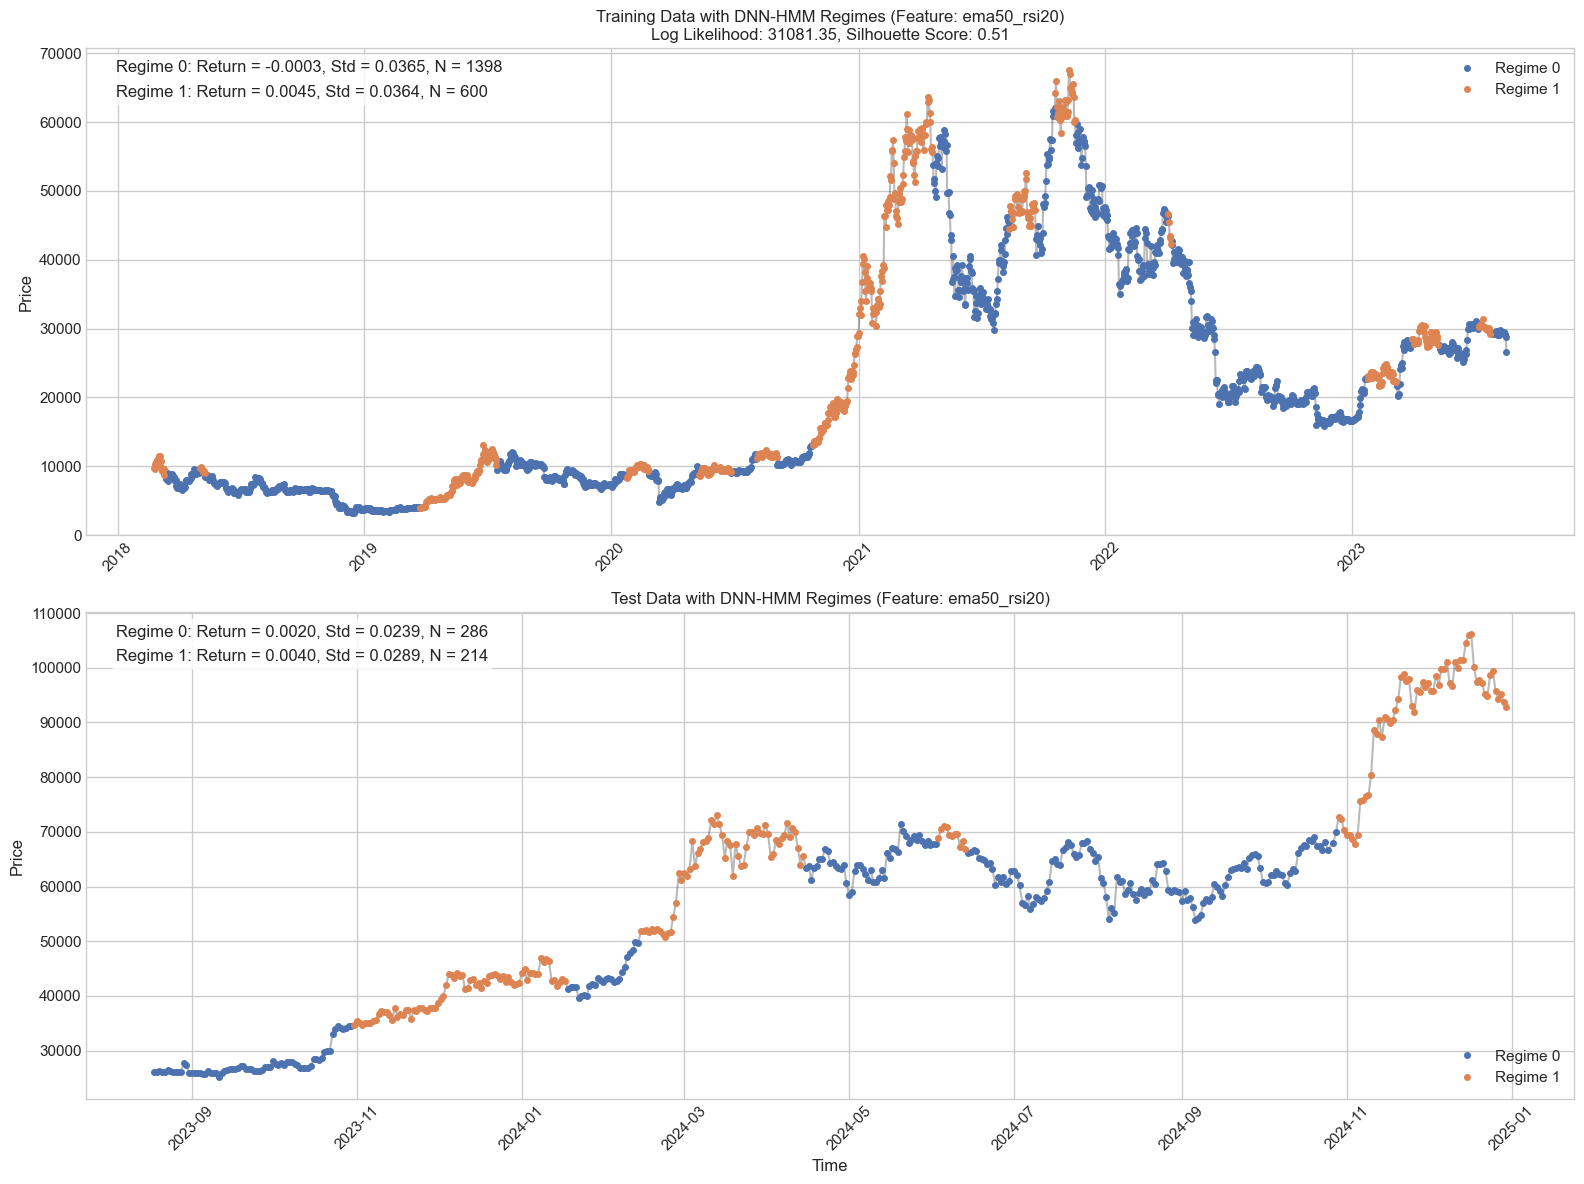


=== DNN-HMM Analysis using feature: ema50_rsi20 ===

=== Training Data Regime Statistics ===
Regime 0:
  Mean Return: -0.000283
  Std Dev: 0.036475
  Count: 1398
  Percentage: 69.97%
Regime 1:
  Mean Return: 0.004493
  Std Dev: 0.036443
  Count: 600
  Percentage: 30.03%

=== Test Data Regime Statistics ===
Regime 0:
  Mean Return: 0.001964
  Std Dev: 0.023907
  Count: 286
  Percentage: 57.20%
Regime 1:
  Mean Return: 0.003980
  Std Dev: 0.028935
  Count: 214
  Percentage: 42.80%
Model saved to dnn_hmm_models/dnnhmm_ema50_rsi20
Model for feature ema50_rsi20 loaded from dnn_hmm_models/dnnhmm_ema50_rsi20


C:\Users\gpari\AppData\Local\Temp\ipykernel_6232\2459338378.py:662: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  nn_model.load_state_dict(torch.load(f"{model_path}/nn_model

In [16]:

# Train and save a model:
results = train_single_feature_dnnhmm(
    X_train, 
    X_test, 
    train_price, 
    test_price, 
    feature_column='ema50_rsi20',
    n_regimes=3, 
    hidden_dims=[64, 32], 
    embedding_dim=16, 
    n_epochs=100,
    hmm_max_iter=100
)

# Load a saved model and make predictions on new data:
loaded_model = load_dnnhmm_model(feature_column='ema50_rsi20')
# new_regimes = predict_regimes_with_saved_model(loaded_model, X_new)

# Visualize the regimes:
# fig = visualize_regimes(new_regimes, prices, title="Market Regimes - New Data")
# plt.savefig("dnn_hmm_output/new_data_regimes.png")

# Analyze returns by regime:
# fig, stats = analyze_returns_by_regime(returns, new_regimes, title="Returns Analysis - New Data")
# plt.savefig("dnn_hmm_output/new_data_returns_analysis.png")


Using device: cpu
Training DNN-HMM with 3 regimes on feature: rsi20
Training data shape after cleaning: (1998, 1)
Scaling data...
Training neural network for feature extraction...
Training neural network for 100 epochs...


C:\Users\gpari\AppData\Roaming\Python\Python311\site-packages\torch\nn\modules\loss.py:608: UserWarning: Using a target size (torch.Size([32, 1])) that is different to the input size (torch.Size([32, 16])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
C:\Users\gpari\AppData\Roaming\Python\Python311\site-packages\torch\nn\modules\loss.py:608: UserWarning: Using a target size (torch.Size([14, 1])) that is different to the input size (torch.Size([14, 16])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 1/100, Loss: 0.450872
Epoch 11/100, Loss: 0.174422
Epoch 21/100, Loss: 0.165292
Epoch 31/100, Loss: 0.155433
Epoch 41/100, Loss: 0.154262
Epoch 51/100, Loss: 0.151934
Epoch 61/100, Loss: 0.155223
Epoch 71/100, Loss: 0.153365
Epoch 81/100, Loss: 0.150832
Epoch 91/100, Loss: 0.149047
Epoch 100/100, Loss: 0.152187
Training HMM with 3 regimes on embeddings...
Iteration 0, Log-likelihood: -91770.7109
  State 0: 1326 samples (66.4%)
  State 1: 0 samples (0.0%)
  State 2: 672 samples (33.6%)
Converged at iteration 6 with log-likelihood: -10703.3711
Generating regime predictions...
Silhouette score: 0.6133
Test data shape after cleaning: (500, 1)


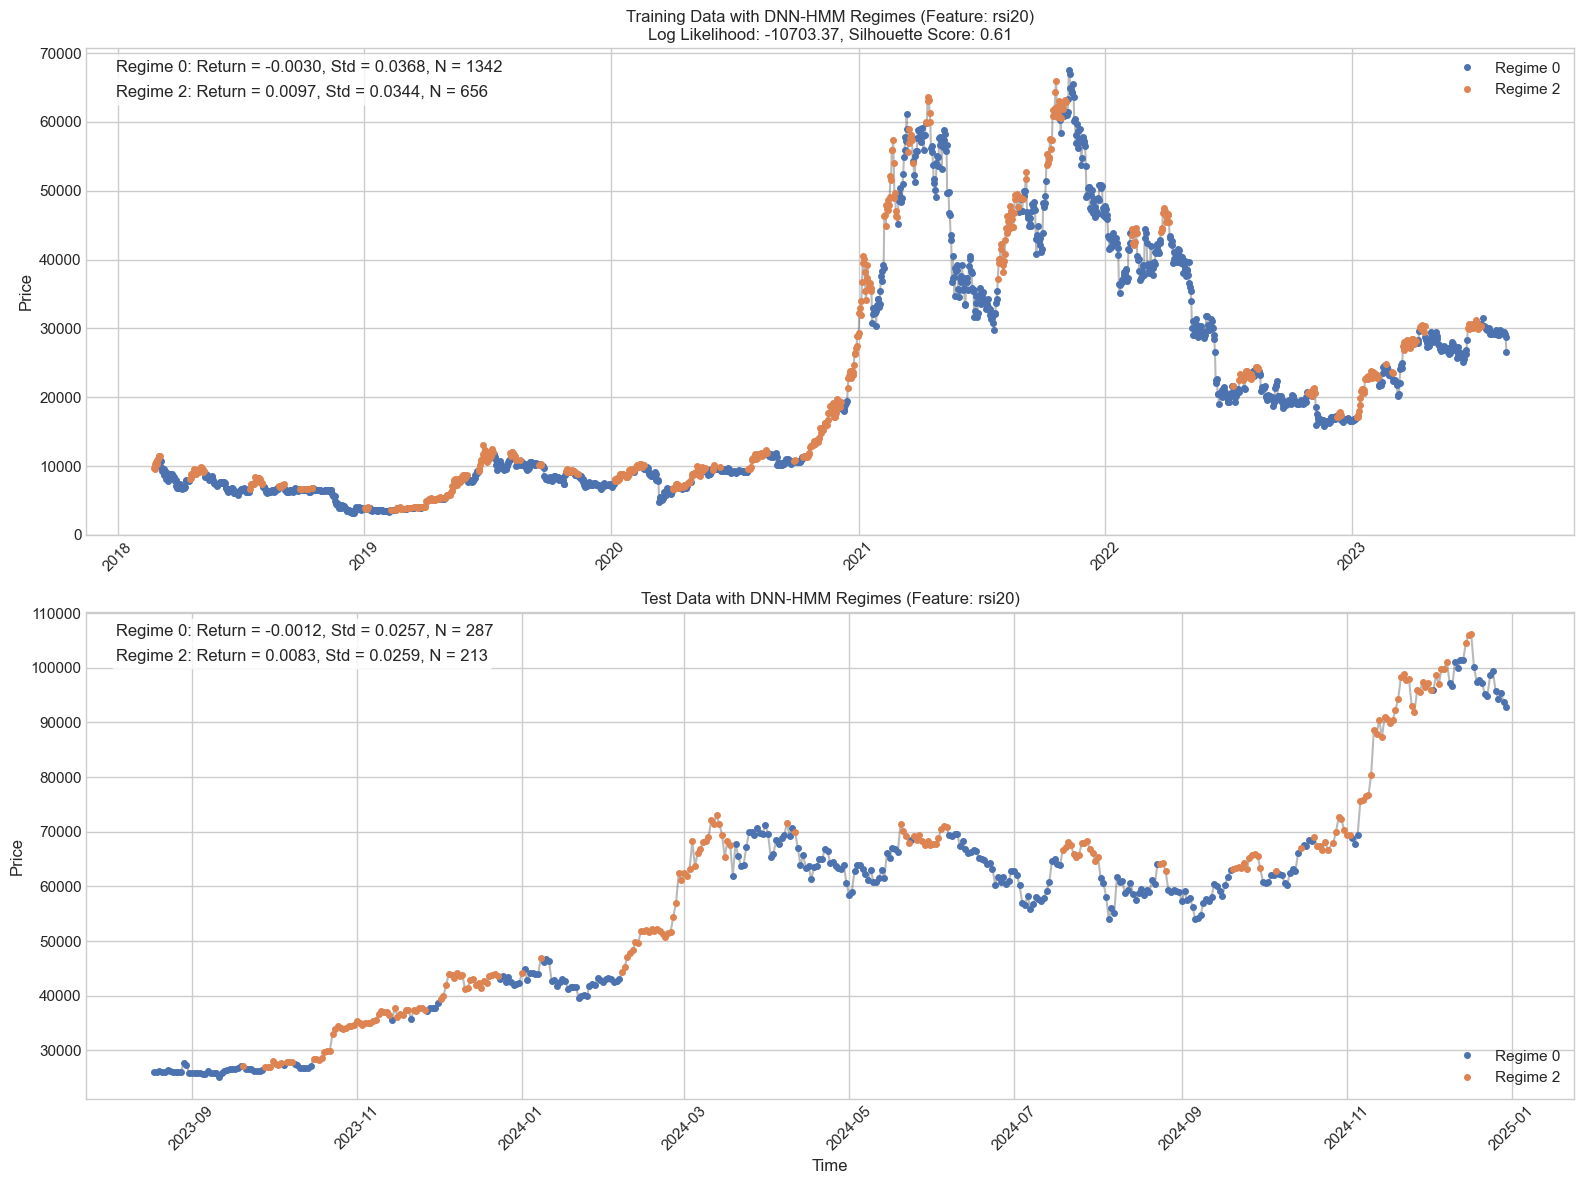


=== DNN-HMM Analysis using feature: rsi20 ===

=== Training Data Regime Statistics ===
Regime 0:
  Mean Return: -0.003030
  Std Dev: 0.036816
  Count: 1342
  Percentage: 67.17%
Regime 2:
  Mean Return: 0.009706
  Std Dev: 0.034390
  Count: 656
  Percentage: 32.83%

=== Test Data Regime Statistics ===
Regime 0:
  Mean Return: -0.001229
  Std Dev: 0.025676
  Count: 287
  Percentage: 57.40%
Regime 2:
  Mean Return: 0.008291
  Std Dev: 0.025889
  Count: 213
  Percentage: 42.60%
Model saved to dnn_hmm_models/dnnhmm_rsi20
Model for feature rsi20 loaded from dnn_hmm_models/dnnhmm_rsi20


C:\Users\gpari\AppData\Local\Temp\ipykernel_6232\2459338378.py:662: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  nn_model.load_state_dict(torch.load(f"{model_path}/nn_model

In [17]:
results = train_single_feature_dnnhmm(
    X_train, 
    X_test, 
    train_price, 
    test_price, 
    feature_column='rsi20',
    n_regimes=3, 
    hidden_dims=[64, 32], 
    embedding_dim=16, 
    n_epochs=100,
    hmm_max_iter=100
)

# Load a saved model and make predictions on new data:
loaded_model = load_dnnhmm_model(feature_column='rsi20')

### Conclusion

For daily data!
The standard HMM model continues to perform better with (fg + pct_fg) combination. The rsi20 provides a better alternative than the ema50_rsi20 (ss=0.30 vs ss=0.14), probably because it follows a normal distribution. However the regime is not as continuous as the fg+pct_fg. The DNN-HMM model for daily data only detects two regimes for the rsi20 and the ema50_rsi20. The ema50_rsi20 could be split into three regimes based on its value:
1) RSI = 0
2) RSI = 100
3) RSI > 0 and RSI < 100
This could be another option for evaluation.
Four hourly data it seems that the DNN_HMM model detects 3 regimes with a silhouette score ranging from 0.82 till 0.87, after multiple re trials.
It makes sense that our DNN-HMM model will perform better with hourly data since NNs need lots of data for training.

### RSI clustering

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import seaborn as sns

def analyze_stock_regimes(X_train, X_test, train_price, test_price):
    """
    Analyze stock price regimes based on ema50_rsi20 indicator.
    
    Parameters:
    - X_train: DataFrame with training features ('fg', 'pct_fg', 'ema50_rsi20', 'rsi20', 'Returns')
    - X_test: DataFrame with testing features
    - train_price: Series or array with training price data
    - test_price: Series or array with testing price data
    
    Returns:
    - Dictionary with regime analysis results
    """
    # Combine data for full analysis
    X_combined = pd.concat([X_train, X_test], axis=0)
    prices_combined = np.concatenate([train_price, test_price])
    
    # Identify regimes based on ema50_rsi20
    regimes = pd.Series(index=X_combined.index, dtype='object')
    
    # Apply regime classification rules
    regime1_mask = X_combined['ema50_rsi20'] < 10
    regime3_mask = X_combined['ema50_rsi20'] > 90
    regime2_mask = (X_combined['ema50_rsi20'] > 10) & (X_combined['ema50_rsi20'] < 90)
    
    regimes[regime1_mask] = 'Regime 1'  # Red
    regimes[regime2_mask] = 'Regime 2'  # Blue
    regimes[regime3_mask] = 'Regime 3'  # Green
    
    # Debug regime identification
    print("\n==== Regime Identification ====")
    print(f"Total data points: {len(regimes)}")
    print(f"Regime 1 (Red) count: {regime1_mask.sum()}")
    print(f"Regime 2 (Blue) count: {regime2_mask.sum()}")
    print(f"Regime 3 (Green) count: {regime3_mask.sum()}")
    
    # Check for any unclassified points
    unclassified = len(regimes) - (regime1_mask.sum() + regime2_mask.sum() + regime3_mask.sum())
    if unclassified > 0:
        print(f"Warning: {unclassified} data points could not be classified into any regime.")
        print("Checking for potential issues with ema50_rsi20 values:")
        print(X_combined['ema50_rsi20'].describe())
        # Fill any unclassified points (shouldn't happen with proper data)
        regimes[regimes.isna()] = 'Unclassified'
    
    # Split regimes back to train and test
    train_regimes = regimes.iloc[:len(X_train)]
    test_regimes = regimes.iloc[len(X_train):]
    
    # Calculate returns in each regime
    regime_returns = {}
    combined_returns = X_combined['Returns'].copy()
    
    for regime in ['Regime 1', 'Regime 2', 'Regime 3']:
        regime_mask = regimes == regime
        if regime_mask.sum() > 0:
            regime_returns[regime] = {
                'mean': combined_returns[regime_mask].mean() * 100,
                'std': combined_returns[regime_mask].std() * 100,
                'count': regime_mask.sum(),
                'percentage': (regime_mask.sum() / len(regimes)) * 100
            }
        else:
            # Include empty regimes in results
            regime_returns[regime] = {
                'mean': np.nan,
                'std': np.nan,
                'count': 0,
                'percentage': 0.0
            }
            print(f"Warning: {regime} has no data points.")
    
    # Calculate silhouette score for regime classification
    # Need to use only numerical features for silhouette score
    features_for_silhouette = ['ema50_rsi20', 'rsi20', 'Returns']
    silhouette = None
    
    # Only calculate silhouette if we have at least two regimes with data
    active_regimes = sum(1 for r in regime_returns.values() if r['count'] > 0)
    if active_regimes >= 2:
        # Convert regimes to numeric labels for silhouette score
        regime_map = {'Regime 1': 0, 'Regime 2': 1, 'Regime 3': 2, 'Unclassified': -1}
        regime_labels = regimes.map(regime_map).values
        
        # Filter out any unclassified points
        valid_mask = regime_labels != -1
        if valid_mask.sum() > 0:
            # Standardize features for silhouette score
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X_combined[features_for_silhouette])
            
            # Filter out any NaN values
            nan_mask = ~np.isnan(X_scaled).any(axis=1)
            final_mask = valid_mask & nan_mask
            
            if final_mask.sum() > 0 and len(np.unique(regime_labels[final_mask])) > 1:
                silhouette = silhouette_score(X_scaled[final_mask], regime_labels[final_mask])
            else:
                print("Could not calculate silhouette score: insufficient valid data or regimes.")
        else:
            print("Could not calculate silhouette score: no valid regime labels.")
    else:
        print(f"Could not calculate silhouette score: only {active_regimes} regimes with data (need at least 2).")
    
    return {
        'train_regimes': train_regimes,
        'test_regimes': test_regimes,
        'regime_returns': regime_returns,
        'silhouette_score': silhouette,
        'regime_counts': {
            'Regime 1': regime1_mask.sum(),
            'Regime 2': regime2_mask.sum(),
            'Regime 3': regime3_mask.sum()
        }
    }

def plot_regimes(X_train, X_test, train_price, test_price, analysis_results):
    """
    Plot stock prices colored by regime.
    
    Parameters:
    - X_train: DataFrame with training features
    - X_test: DataFrame with testing features
    - train_price: Series or array with training price data
    - test_price: Series or array with testing price data
    - analysis_results: Dict with regime analysis results
    """
    # Extract regime data
    train_regimes = analysis_results['train_regimes']
    test_regimes = analysis_results['test_regimes']
    
    # Create a figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=False)
    
    # Color mapping
    color_map = {
        'Regime 1': 'red',      # ema50_rsi20 = 0
        'Regime 2': 'blue',     # 0 < ema50_rsi20 < 100
        'Regime 3': 'green',    # ema50_rsi20 = 100
        'Unclassified': 'gray'  # In case there are unclassified points
    }
    
    # Plot training data
    train_indices = X_train.index if hasattr(X_train, 'index') else np.arange(len(train_price))
    
    # Connect points with a light gray line for visual clarity (plot first so points appear on top)
    ax1.plot(train_indices, train_price, color='lightgray', alpha=0.3, linewidth=0.5)
    
    # Plot each regime separately
    for regime in ['Regime 1', 'Regime 2', 'Regime 3']:
        mask = train_regimes == regime
        if mask.sum() > 0:
            ax1.scatter(train_indices[mask], train_price[mask], 
                      color=color_map[regime], label=f"{regime} (n={mask.sum()})", s=10, alpha=0.7)
    
    # Handle unclassified points if any
    mask = train_regimes == 'Unclassified'
    if mask.sum() > 0:
        ax1.scatter(train_indices[mask], train_price[mask], 
                  color=color_map['Unclassified'], label=f"Unclassified (n={mask.sum()})", s=10, alpha=0.7)
    
    ax1.set_title('Training Data: Stock Price by Regime')
    ax1.set_ylabel('Price')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot testing data
    test_indices = X_test.index if hasattr(X_test, 'index') else np.arange(len(test_price)) + len(train_price)
    
    # Connect points with a light gray line
    ax2.plot(test_indices, test_price, color='lightgray', alpha=0.3, linewidth=0.5)
    
    # Plot each regime separately
    for regime in ['Regime 1', 'Regime 2', 'Regime 3']:
        mask = test_regimes == regime
        if mask.sum() > 0:
            ax2.scatter(test_indices[mask], test_price[mask], 
                      color=color_map[regime], label=f"{regime} (n={mask.sum()})", s=10, alpha=0.7)
    
    # Handle unclassified points if any
    mask = test_regimes == 'Unclassified'
    if mask.sum() > 0:
        ax2.scatter(test_indices[mask], test_price[mask], 
                  color=color_map['Unclassified'], label=f"Unclassified (n={mask.sum()})", s=10, alpha=0.7)
    
    ax2.set_title('Testing Data: Stock Price by Regime')
    ax2.set_xlabel('Time')
    ax2.set_ylabel('Price')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Create an additional figure for regime return analysis
    fig2, ax3 = plt.subplots(figsize=(12, 6))
    
    # Prepare data for bar chart
    regimes = []
    means = []
    stds = []
    counts = []
    colors = []
    
    for regime, stats in analysis_results['regime_returns'].items():
        if stats['count'] > 0:  # Only include regimes with data
            regimes.append(regime)
            means.append(stats['mean'])
            stds.append(stats['std'])
            counts.append(stats['count'])
            colors.append(color_map[regime])
    
    if regimes:  # Only create bar chart if we have data
        # Bar chart of returns by regime
        bars = ax3.bar(regimes, means, yerr=stds, capsize=10, color=colors, alpha=0.7)
        
        # Add count annotations
        for i, bar in enumerate(bars):
            height = bar.get_height() if not np.isnan(bar.get_height()) else 0
            ax3.text(bar.get_x() + bar.get_width()/2., height + (0.1 if height > 0 else -0.1),
                    f'n={counts[i]}', ha='center', va='bottom' if height > 0 else 'top')
        
        ax3.set_title('Average Returns by Regime')
        ax3.set_ylabel('Return (%)')
        ax3.grid(True, alpha=0.3)
        
        # Add silhouette score if available
        if analysis_results['silhouette_score'] is not None:
            plt.figtext(0.5, 0.01, f"Silhouette Score: {analysis_results['silhouette_score']:.4f}", 
                      ha='center', fontsize=12, bbox=dict(facecolor='white', alpha=0.8))
        
        plt.tight_layout()
    else:
        ax3.text(0.5, 0.5, "No regime data available for bar chart", 
               ha='center', va='center', fontsize=12)
    
    # Create an additional figure for regime distribution
    fig3, ax4 = plt.subplots(figsize=(10, 6))
    
    # Prepare data for pie chart
    regime_counts = analysis_results['regime_counts']
    labels = [f"{regime} (n={count})" for regime, count in regime_counts.items() if count > 0]
    counts = [count for count in regime_counts.values() if count > 0]
    colors = [color_map[regime] for regime, count in regime_counts.items() if count > 0]
    
    if counts:  # Only create pie chart if we have data
        ax4.pie(counts, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, shadow=True)
        ax4.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
        ax4.set_title('Distribution of Regimes')
    else:
        ax4.text(0.5, 0.5, "No regime data available for pie chart", 
               ha='center', va='center', fontsize=12)
    
    return fig, fig2, fig3

def display_regime_info(analysis_results):
    """
    Display information about each regime.
    
    Parameters:
    - analysis_results: Dict with regime analysis results
    """
    print("\n===== Regime Analysis =====")
    
    # Display regime counts
    print("\nRegime Distribution:")
    for regime, count in analysis_results['regime_counts'].items():
        print(f"  {regime}: {count} observations ({count/sum(analysis_results['regime_counts'].values())*100:.1f}% of data)")
    
    # Display regime returns
    print("\nReturns by Regime:")
    regime_returns = analysis_results['regime_returns']
    for regime, stats in regime_returns.items():
        if stats['count'] > 0:
            print(f"\n{regime}:")
            print(f"  Average Return: {stats['mean']:.2f}%")
            print(f"  Standard Deviation: {stats['std']:.2f}%")
            print(f"  Count: {stats['count']} observations ({stats['percentage']:.1f}% of data)")
        else:
            print(f"\n{regime}: No data points")
    
    # Display silhouette score
    if analysis_results['silhouette_score'] is not None:
        print(f"\nSilhouette Score: {analysis_results['silhouette_score']:.4f}")
        print("(Score ranges from -1 to 1, with higher values indicating better defined clusters)")
    else:
        print("\nSilhouette Score could not be calculated.")
    
    # Calculate additional statistics
    train_regimes = analysis_results['train_regimes']
    test_regimes = analysis_results['test_regimes']
    
    print("\nRegime Distribution by Dataset:")
    print("  Training data:", train_regimes.value_counts().to_dict())
    print("  Testing data:", test_regimes.value_counts().to_dict())

In [42]:
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from tqdm import tqdm

def optimize_regime_boundaries(X_train, step_size=5, verbose=True):
    """
    Find optimal regime boundaries to maximize silhouette score.
    
    Parameters:
    - X_train: DataFrame with training features (must include 'ema50_rsi20', 'rsi20', 'Returns')
    - step_size: Resolution for grid search (smaller = more precise but slower)
    - verbose: Whether to print progress information
    
    Returns:
    - Dictionary with optimal parameters and results
    """
    if verbose:
        print("Starting optimization of regime boundaries...")
    
    # Features to use for silhouette score calculation
    features_for_silhouette = ['ema50_rsi20', 'rsi20', 'Returns']
    
    # Standardize features for silhouette score
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_train[features_for_silhouette])
    
    # Define the search space
    lower_bounds = np.arange(0, 50, step_size)  # From 0 to 45 by step_size
    upper_bounds = np.arange(50, 100 + step_size, step_size)  # From 50 to 100 by step_size
    
    # Initialize results tracking
    best_score = -1  # Silhouette scores range from -1 to 1
    best_params = None
    all_results = []
    
    # Define a helper function to compute silhouette score with specific boundaries
    def compute_silhouette(lower_bound, upper_bound):
        # Create regime labels
        labels = np.zeros(len(X_train), dtype=int)
        
        # Assign regimes based on boundaries
        regime1_mask = X_train['ema50_rsi20'] <= lower_bound
        regime3_mask = X_train['ema50_rsi20'] >= upper_bound
        regime2_mask = ~(regime1_mask | regime3_mask)
        
        # Check that all three regimes have data
        regime_counts = [regime1_mask.sum(), regime2_mask.sum(), regime3_mask.sum()]
        
        if min(regime_counts) < 2:
            # Need at least 2 samples per cluster for silhouette score
            return -2, regime_counts  # Return invalid score
        
        # Assign numeric labels for silhouette calculation
        labels[regime1_mask] = 0
        labels[regime2_mask] = 1
        labels[regime3_mask] = 2
        
        try:
            score = silhouette_score(X_scaled, labels)
            return score, regime_counts
        except Exception as e:
            if verbose:
                print(f"Error computing silhouette score: {e}")
            return -2, regime_counts
    
    # Perform grid search
    total_iterations = len(lower_bounds) * len(upper_bounds)
    if verbose:
        print(f"Searching across {total_iterations} parameter combinations...")
    
    for lower in tqdm(lower_bounds, desc="Lower bound", disable=not verbose):
        for upper in upper_bounds:
            # Skip invalid combinations
            if lower >= upper:
                continue
            
            # Compute silhouette score for this boundary pair
            score, regime_counts = compute_silhouette(lower, upper)
            
            # Store result
            result = {
                'lower_bound': lower,
                'upper_bound': upper,
                'silhouette_score': score,
                'regime_counts': regime_counts
            }
            all_results.append(result)
            
            # Update best if improved
            if score > best_score:
                best_score = score
                best_params = {'lower_bound': lower, 'upper_bound': upper}
                if verbose:
                    print(f"New best: lower={lower}, upper={upper}, score={score:.4f}, counts={regime_counts}")
    
    if verbose:
        print(f"\nOptimization complete. Best silhouette score: {best_score:.4f}")
        print(f"Optimal parameters: regime1 < {best_params['lower_bound']}, " 
              f"regime2 between {best_params['lower_bound']} and {best_params['upper_bound']}, "
              f"regime3 > {best_params['upper_bound']}")
    
    # Create visualization of parameter space
    results_df = pd.DataFrame(all_results)
    
    # Filter out invalid scores
    valid_results = results_df[results_df['silhouette_score'] > -2]
    
    if not valid_results.empty:
        # Create heatmap
        pivot_table = valid_results.pivot_table(
            index='lower_bound', 
            columns='upper_bound', 
            values='silhouette_score',
            aggfunc='mean'
        )
        
        plt.figure(figsize=(10, 8))
        plt.imshow(pivot_table, cmap='viridis', interpolation='nearest', aspect='auto')
        plt.colorbar(label='Silhouette Score')
        plt.xlabel('Upper Boundary')
        plt.ylabel('Lower Boundary')
        plt.title('Silhouette Score by Regime Boundaries')
        
        # Add axis labels
        plt.xticks(np.arange(len(pivot_table.columns)), pivot_table.columns)
        plt.yticks(np.arange(len(pivot_table.index)), pivot_table.index)
        
        # Mark the best parameters
        if best_params:
            best_x = list(pivot_table.columns).index(best_params['upper_bound'])
            best_y = list(pivot_table.index).index(best_params['lower_bound'])
            plt.plot(best_x, best_y, 'r*', markersize=15)
            plt.annotate('Best', (best_x, best_y), xytext=(best_x + 0.5, best_y + 0.5),
                        arrowprops=dict(facecolor='black', shrink=0.05))
        
        plt.tight_layout()
        plt.show()
    
    # Return optimal parameters and all results
    return {
        'best_params': best_params,
        'best_score': best_score,
        'all_results': all_results
    }

def analyze_optimal_regime(X_train, train_price, best_params):
    """
    Analyze stock data with optimal regime boundaries.
    
    Parameters:
    - X_train: DataFrame with training features
    - train_price: Series or array with training price data
    - best_params: Dictionary with optimal boundary parameters
    
    Returns:
    - Analysis results with regime information
    """
    lower_bound = best_params['lower_bound']
    upper_bound = best_params['upper_bound']
    
    # Create regimes
    regimes = pd.Series(index=X_train.index, dtype='object')
    
    # Apply optimized regime classification rules
    regime1_mask = X_train['ema50_rsi20'] <= lower_bound
    regime3_mask = X_train['ema50_rsi20'] >= upper_bound
    regime2_mask = ~(regime1_mask | regime3_mask)
    
    regimes[regime1_mask] = 'Regime 1'  # Red
    regimes[regime2_mask] = 'Regime 2'  # Blue
    regimes[regime3_mask] = 'Regime 3'  # Green
    
    # Calculate returns in each regime
    regime_returns = {}
    returns = X_train['Returns'].copy()
    
    for regime in ['Regime 1', 'Regime 2', 'Regime 3']:
        regime_mask = regimes == regime
        if regime_mask.sum() > 0:
            regime_returns[regime] = {
                'mean': returns[regime_mask].mean() * 100,
                'std': returns[regime_mask].std() * 100,
                'count': regime_mask.sum(),
                'percentage': (regime_mask.sum() / len(regimes)) * 100
            }
        else:
            regime_returns[regime] = {
                'mean': np.nan,
                'std': np.nan,
                'count': 0,
                'percentage': 0.0
            }
    
    # Calculate silhouette score
    features_for_silhouette = ['ema50_rsi20', 'rsi20', 'Returns']
    
    # Only calculate silhouette if we have at least two regimes with data
    active_regimes = sum(1 for r in regime_returns.values() if r['count'] > 0)
    
    if active_regimes >= 2:
        # Convert regimes to numeric labels for silhouette score
        regime_map = {'Regime 1': 0, 'Regime 2': 1, 'Regime 3': 2}
        regime_labels = regimes.map(regime_map).values
        
        # Standardize features for silhouette score
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_train[features_for_silhouette])
        
        # Calculate the silhouette score
        silhouette = silhouette_score(X_scaled, regime_labels)
    else:
        silhouette = None
    
    # Return analysis results
    return {
        'regimes': regimes,
        'regime_returns': regime_returns,
        'silhouette_score': silhouette,
        'regime_counts': {
            'Regime 1': regime1_mask.sum(),
            'Regime 2': regime2_mask.sum(),
            'Regime 3': regime3_mask.sum()
        },
        'params': {
            'lower_bound': lower_bound,
            'upper_bound': upper_bound
        }
    }

def plot_optimal_regimes(X_train, train_price, analysis_results):
    """
    Plot stock prices with optimal regimes.
    
    Parameters:
    - X_train: DataFrame with training features
    - train_price: Series or array with training price data
    - analysis_results: Dict with regime analysis results
    
    Returns:
    - Figure objects
    """
    # Extract regime data
    regimes = analysis_results['regimes']
    
    # Create two figures - one for price by regime, one for returns analysis
    fig1, ax1 = plt.subplots(figsize=(15, 8))
    
    # Color mapping
    color_map = {
        'Regime 1': 'red',      # Low ema50_rsi20
        'Regime 2': 'blue',     # Middle ema50_rsi20
        'Regime 3': 'green',    # High ema50_rsi20
    }
    
    # Plot training data
    train_indices = X_train.index if hasattr(X_train, 'index') else np.arange(len(train_price))
    
    # Connect points with a light gray line for visual clarity
    ax1.plot(train_indices, train_price, color='lightgray', alpha=0.3, linewidth=0.5)
    
    # Plot each regime separately
    for regime in ['Regime 1', 'Regime 2', 'Regime 3']:
        mask = regimes == regime
        if mask.sum() > 0:
            ax1.scatter(train_indices[mask], train_price[mask], 
                      color=color_map[regime], label=f"{regime} (n={mask.sum()})", s=10, alpha=0.7)
    
    ax1.set_title(f'Stock Price by Optimal Regimes\n'
                 f'Lower Bound: {analysis_results["params"]["lower_bound"]}, '
                 f'Upper Bound: {analysis_results["params"]["upper_bound"]}, '
                 f'Silhouette: {analysis_results["silhouette_score"]:.4f}')
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Price')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Create an additional figure for regime return analysis
    fig2, ax2 = plt.subplots(figsize=(12, 6))
    
    # Prepare data for bar chart
    regimes = []
    means = []
    stds = []
    counts = []
    colors = []
    
    for regime, stats in analysis_results['regime_returns'].items():
        if stats['count'] > 0:  # Only include regimes with data
            regimes.append(regime)
            means.append(stats['mean'])
            stds.append(stats['std'])
            counts.append(stats['count'])
            colors.append(color_map[regime])
    
    # Bar chart of returns by regime
    bars = ax2.bar(regimes, means, yerr=stds, capsize=10, color=colors, alpha=0.7)
    
    # Add count annotations
    for i, bar in enumerate(bars):
        height = bar.get_height() if not np.isnan(bar.get_height()) else 0
        ax2.text(bar.get_x() + bar.get_width()/2., height + (0.1 if height > 0 else -0.1),
                f'n={counts[i]}', ha='center', va='bottom' if height > 0 else 'top')
    
    ax2.set_title('Average Returns by Optimal Regime')
    ax2.set_ylabel('Return (%)')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Create a third figure showing regime distribution
    fig3, ax3 = plt.subplots(figsize=(10, 6))
    
    # Prepare data for pie chart
    regime_counts = analysis_results['regime_counts']
    labels = [f"{regime} (n={count})" for regime, count in regime_counts.items() if count > 0]
    counts = [count for count in regime_counts.values() if count > 0]
    colors = [color_map[regime] for regime, count in regime_counts.items() if count > 0]
    
    ax3.pie(counts, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, shadow=True)
    ax3.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
    ax3.set_title('Distribution of Optimal Regimes')
    
    return fig1, fig2, fig3

Starting optimization of regime boundaries...
Searching across 110 parameter combinations...


Lower bound:   0%|                                                                              | 0/10 [00:00<?, ?it/s]

New best: lower=0, upper=50, score=0.1856, counts=[450, 558, 990]
New best: lower=0, upper=55, score=0.1875, counts=[450, 584, 964]


Lower bound:  10%|███████                                                               | 1/10 [00:01<00:10,  1.15s/it]

New best: lower=5, upper=50, score=0.1937, counts=[632, 376, 990]
New best: lower=5, upper=55, score=0.1993, counts=[632, 402, 964]
New best: lower=5, upper=60, score=0.2016, counts=[632, 425, 941]
New best: lower=5, upper=65, score=0.2025, counts=[632, 448, 918]


...

New best: lower=35, upper=95, score=0.2108, counts=[910, 409, 679]
New best: lower=40, upper=80, score=0.2120, counts=[946, 241, 811]


Lower bound:  90%|███████████████████████████████████████████████████████████████       | 9/10 [00:08<00:00,  1.04it/s]

New best: lower=40, upper=95, score=0.2150, counts=[946, 373, 679]


Lower bound: 100%|█████████████████████████████████████████████████████████████████████| 10/10 [00:09<00:00,  1.03it/s]

New best: lower=45, upper=95, score=0.2164, counts=[978, 341, 679]

Optimization complete. Best silhouette score: 0.2164
Optimal parameters: regime1 < 45, regime2 between 45 and 95, regime3 > 95


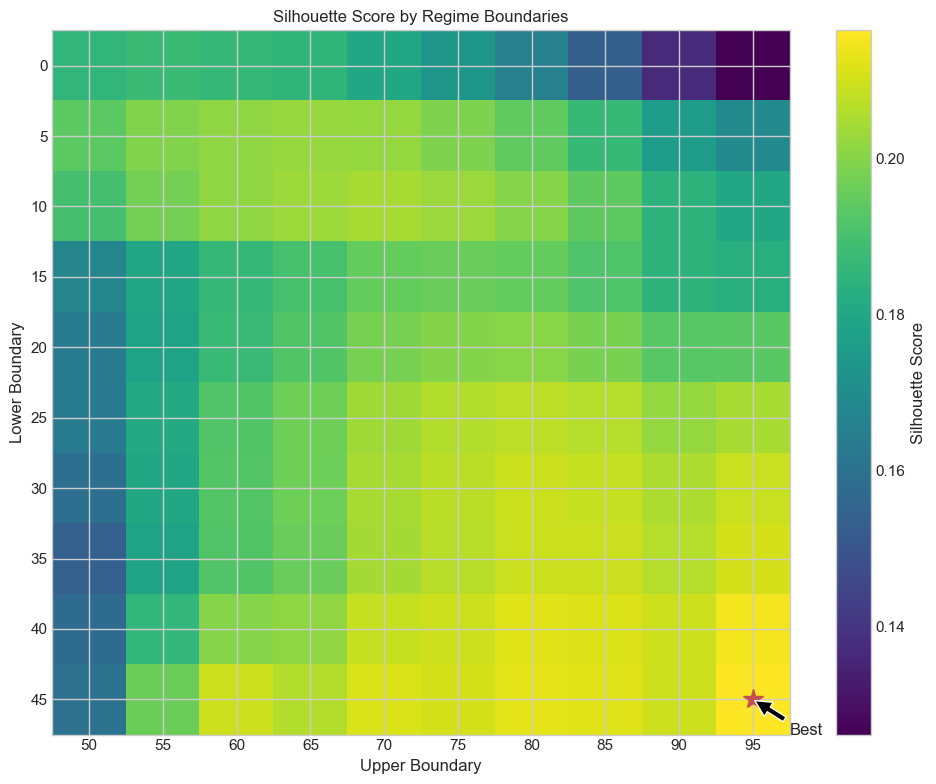

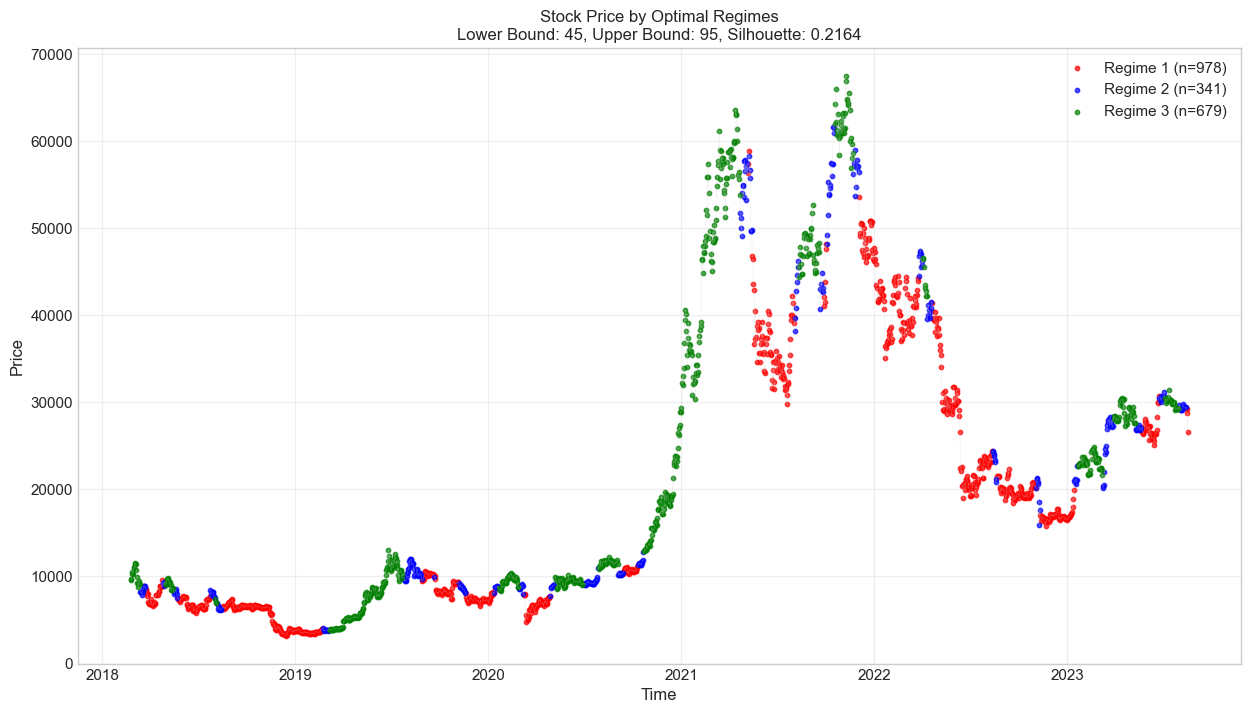

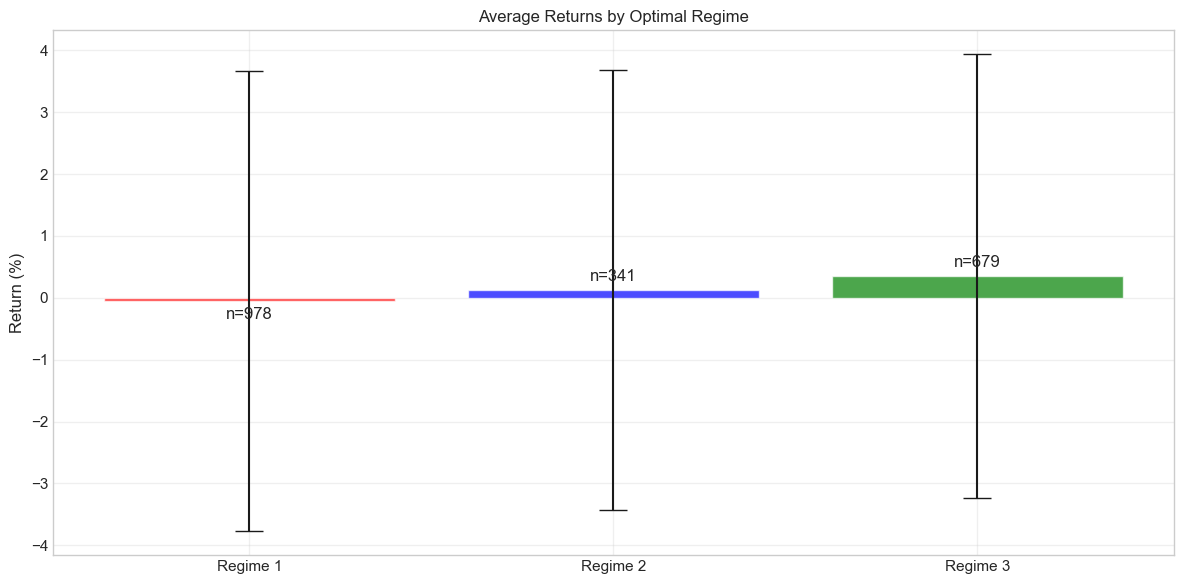

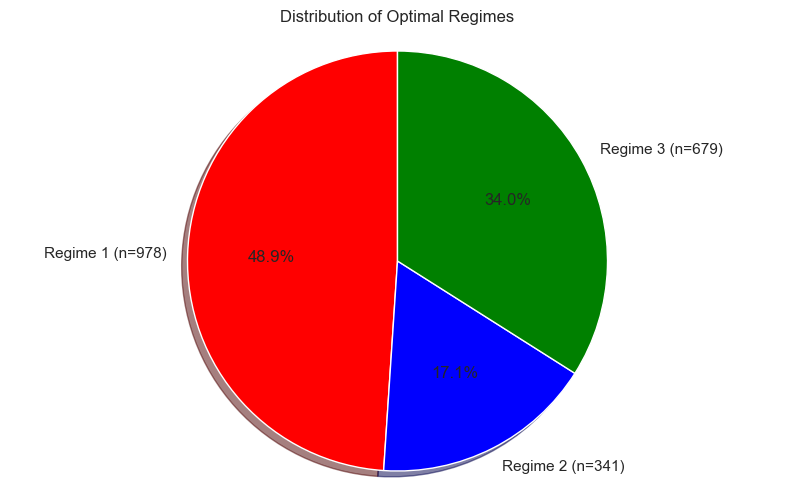

In [43]:
optimization_results = optimize_regime_boundaries(X_train, step_size=5)
best_params = optimization_results['best_params']

# Step 2: Analyze the stock data with optimal boundaries
optimal_analysis = analyze_optimal_regime(X_train, train_price, best_params)

# Step 3: Visualize the results
fig1, fig2, fig3 = plot_optimal_regimes(X_train, train_price, optimal_analysis)
plt.show()